In [ ]:
import numpy as np

In [ ]:
import gpjax
print(gpjax.__version__)  # Should print 0.15.0

c:\Users\ISaha\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.18.0


In [ ]:
import numpyro
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
#import jax
import jax.numpy as jnp
#import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict


field=bd1    n_ctrl= 5  wavelength=  250 m  amp_ratio=-0.04+/-0.05  corr=-0.04+/-0.04  (n=6)
field=bd1    n_ctrl=10  wavelength=  250 m  amp_ratio= 0.04+/-0.07  corr= 0.04+/-0.07  (n=6)
field=bd1    n_ctrl=15  wavelength=  250 m  amp_ratio= 0.06+/-0.06  corr= 0.06+/-0.05  (n=6)
field=bd1    n_ctrl=20  wavelength=  250 m  amp_ratio=-0.00+/-0.06  corr= 0.01+/-0.06  (n=6)
field=bd1    n_ctrl= 5  wavelength=  350 m  amp_ratio= 0.07+/-0.07  corr= 0.04+/-0.07  (n=6)
field=bd1    n_ctrl=10  wavelength=  350 m  amp_ratio= 0.02+/-0.10  corr= 0.03+/-0.09  (n=6)
field=bd1    n_ctrl=15  wavelength=  350 m  amp_ratio=-0.05+/-0.10  corr=-0.05+/-0.11  (n=6)
field=bd1    n_ctrl=20  wavelength=  350 m  amp_ratio= 0.06+/-0.10  corr= 0.08+/-0.12  (n=6)
field=bd1    n_ctrl= 5  wavelength=  500 m  amp_ratio=-0.01+/-0.07  corr=-0.01+/-0.06  (n=6)
field=bd1    n_ctrl=10  wavelength=  500 m  amp_ratio= 0.00+/-0.05  corr= 0.00+/-0.05  (n=6)
field=bd1    n_ctrl=15  wavelength=  500 m  amp_ratio= 0.01+/-0.03  co

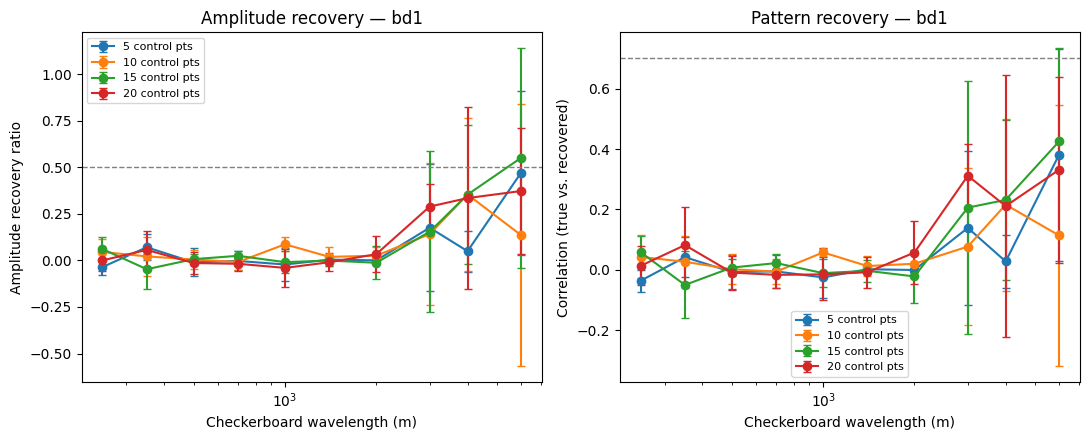

Saved resolution-curve figure to resolution_curves.png


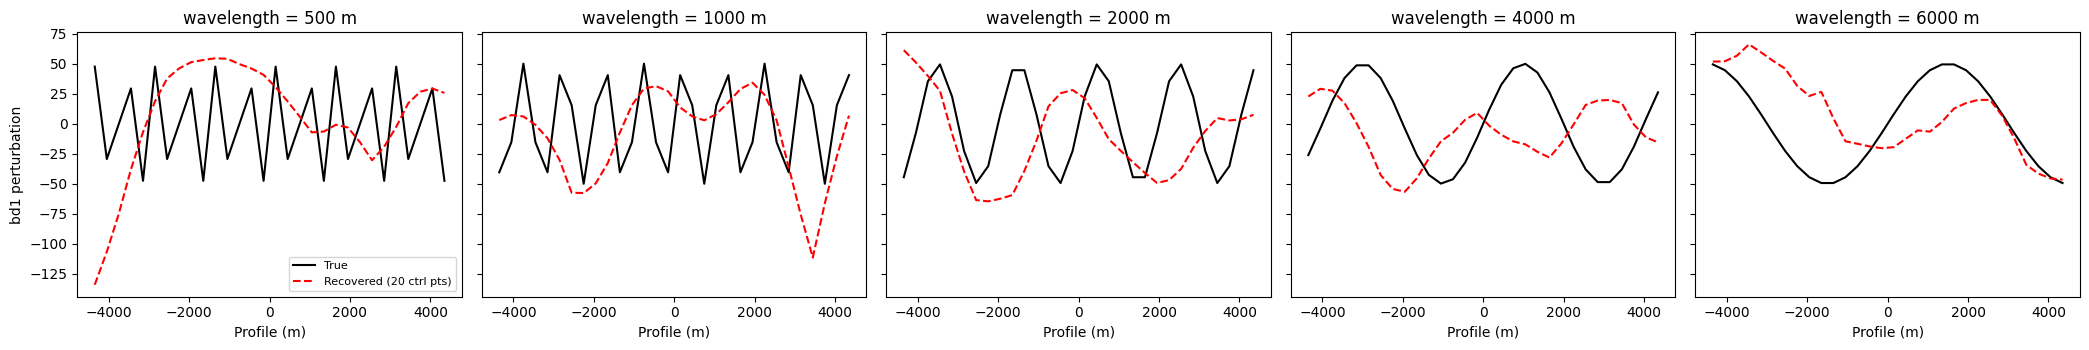

Saved example-recovery figure to example_recovery.png


In [ ]:

import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ======================================================================
# 1. YOUR FORWARD MODEL -- copied verbatim, not modified
# ======================================================================

def g_anomaly(x, A, m, D, d, rho):
    G = 6.67 * (10 ** -6)
    r1 = (((x - A) + (0.5 * m)) ** 2) + ((d) ** 2)
    r2 = (((x - A) + (0.5 * m)) ** 2) + ((D) ** 2)
    r3 = (((x - A) - (0.5 * m)) ** 2) + ((d) ** 2)
    r4 = (((x - A) - (0.5 * m)) ** 2) + ((D) ** 2)
    f1 = np.arctan((x - A + (0.5 * m)) / (D)) - np.arctan((x - A - (0.5 * m)) / (D))
    f2 = np.arctan((x - A + (0.5 * m)) / d) - np.arctan((x - A - (0.5 * m)) / d)
    f3 = 0.5 * (x - A) * (np.log10((r2 * r3) / (r1 * r4)))
    f4 = 0.25 * m * (np.log10((r2 * r4) / (r1 * r3)))
    f = ((D) * f1) - (d * f2) + f3 + f4
    g = 2 * G * rho * f  # in milligal
    return g


def g_n_anomaly(N, x, A, m, D, d, rho):
    u = 0
    for i in range(N):
        v = g_anomaly(x, A[i], m[i], D[i], d[i], rho[i])
        u = u + v
    return u


def measure_func_general(x, n, co, wid, bd1, bd2, td, den1, den2):
    """Your measure_func, generalized to take bd1/bd2/den1/den2 as arguments
    instead of closing over module-level globals, so the inversion can pass
    in trial models."""
    return (g_n_anomaly(n, x, co, wid, bd1, td, den1)
            + g_n_anomaly(n, x, co, wid, bd2, bd1, den2))


# ======================================================================
# 2. USER-EDITABLE SETTINGS
# ======================================================================

# --- prism geometry & background model -- defaults = exactly what you pasted.
#     EDIT this whole block if your real Section 3.3.5 run uses n=80 (or a
#     different background) instead of this n=30 example. ---
N_PRISM = 30
CO = np.linspace(-4350, 4350, N_PRISM)          # prism centers
WID = np.full(N_PRISM, 300.0)                   # prism widths
TD = np.full(N_PRISM, 1e-6)                     # top of layer 1 (~surface, fixed, never perturbed)
#BD1_BG = np.array([500, 510, 520, 530, 540, 545, 550, 545, 540, 530, 520, 490, 470,460, 450, 440, 420, 410, 400, 390, 385, 380, 385, 390, 400, 410,420, 430, 460, 470], dtype=float)
#BD2_BG = np.array([800, 790, 780, 770, 760, 755, 750, 755, 760, 770, 780, 810, 830,840, 850, 860, 880, 890, 900, 910, 915, 920, 915, 910, 900, 890,880, 870, 850, 830], dtype=float)
#DEN1_BG = np.array([-100 - i * 3 for i in range(N_PRISM)], dtype=float)
#DEN2_BG = np.array([-220 - i * 2 for i in range(N_PRISM)], dtype=float)

# --- observation stations (matches your X = np.linspace(-5000,5000,50)) ---
N_OBS = 50
X_OBS = np.linspace(-5000, 5000, N_OBS)

# --- which field to run the resolution test on ---
# one of: "bd1", "bd2", "den1", "den2"
PERTURB_FIELD = "bd1"
PERTURB_AMPLITUDE = 50.0           # m for bd1/bd2, kg/m^3 for den1/den2

# --- noise level for the checkerboard test. Your manuscript's MCMC
# likelihood assumes Gaussian noise, std 0.5 mGal -- that is the default
# here. (Note: the compound noise generator in your notebook -- Gaussian
# std 0.3 + random-walk + salt&pepper + systematic -- uses a *different*
# Gaussian std and extra components; that looks like it's for a separate
# noise-robustness stress test, not the resolution test. Worth double-
# checking the 0.3 vs 0.5 is intentional. Set USE_COMPOUND_NOISE=True below
# if you'd rather replicate that full noise model here instead.) ---
NOISE_STD_MGAL = 0.5
USE_COMPOUND_NOISE = False

# --- control-point densities and wavelengths to sweep ---
N_CTRL_LIST = [5,10,15, 20]
WAVELENGTHS_M = [250, 350, 500, 700, 1000, 1400, 2000, 3000, 4000,6000]

# --- noise realizations per (wavelength, n_ctrl) point ---
N_REPEATS = 6

# --- weak Gaussian prior on each control point (std, same units as
# PERTURB_AMPLITUDE). Turns the inversion into a genuine MAP estimate rather
# than unregularized least squares -- keep this wide relative to
# PERTURB_AMPLITUDE so you're testing data resolution, not prior strength. ---
PRIOR_STD = 3.0 * PERTURB_AMPLITUDE

# --- recovery thresholds that define "resolved" ---
AMP_RATIO_THRESHOLD = 0.5
CORR_THRESHOLD = 0.7

# --- optimizer / misc ---
RANDOM_SEED = 20260828


def make_compound_noise(rng, x_shape):
    """Reproduces your notebook's compound noise generator (Gaussian +
    random-walk + salt&pepper + systematic), for use if USE_COMPOUND_NOISE=True."""
    gaussian_noise = rng.normal(0, 0.3, size=x_shape)
    random_steps = rng.normal(0, 0.1, size=x_shape)
    random_walk_noise = np.cumsum(random_steps)
    salt_prob, pepper_prob, noise_level = 0.05, 0.05, 0.05
    salt_and_pepper_noise = rng.choice(
        [0, 1, -1], size=x_shape, p=[1 - (salt_prob + pepper_prob), salt_prob, pepper_prob]
    ) * noise_level
    a, b, c = 0.001, 0.0001, 0.001
    systematic_noise_level = 0.05
    systematic_noise = systematic_noise_level * (
        (a * ((X_OBS * 0.01) ** 2)) + (b * ((X_OBS * 0.01) ** 3)) + c
    )
    return gaussian_noise + random_walk_noise + salt_and_pepper_noise + systematic_noise


# ======================================================================
# 3. REDUCED-BASIS (PIECEWISE-LINEAR CONTROL-POINT) PARAMETERIZATION
# ======================================================================

def make_control_grid(n_ctrl):
    return np.linspace(CO.min(), CO.max(), n_ctrl)


def controls_to_field(ctrl_values, ctrl_x, prism_x=CO):
    """Piecewise-linear interpolation from control points to full prism
    resolution -- matches the reduced-basis parameterization in 3.3.5."""
    return np.interp(prism_x, ctrl_x, ctrl_values)


# ======================================================================
# 4. CHECKERBOARD (SINUSOIDAL) SYNTHETIC MODEL
# ======================================================================

def build_true_field(field_name, wavelength, amplitude):
    bd1 = BD1_BG.copy()
    bd2 = BD2_BG.copy()
    den1 = DEN1_BG.copy()
    den2 = DEN2_BG.copy()

    perturbation = amplitude * np.sin(2.0 * np.pi * CO / wavelength)
    if field_name == "bd1":
        bd1 = bd1 + perturbation
    elif field_name == "bd2":
        bd2 = bd2 + perturbation
    elif field_name == "den1":
        den1 = den1 + perturbation
    elif field_name == "den2":
        den2 = den2 + perturbation
    else:
        raise ValueError(f"Unknown PERTURB_FIELD: {field_name}")

    if np.any(bd1 >= bd2):
        raise ValueError("Perturbation makes bd1 >= bd2 somewhere -- reduce "
                          "PERTURB_AMPLITUDE or check the field being perturbed.")

    return bd1, bd2, den1, den2, perturbation


# ======================================================================
# 5. MAP INVERSION (control points -> best fit to synthetic data)
# ======================================================================

def invert_control_points(d_obs, noise_std, ctrl_x, field_name):
    """
    Fit control-point values for `field_name` (others fixed at background) by
    minimizing [data misfit] + [weak Gaussian prior], via
    scipy.optimize.least_squares with a finite-difference Jacobian (your
    forward model isn't auto-differentiable).
    """
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)  # optimize the PERTURBATION around background

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        bd1, bd2, den1, den2 = BD1_BG.copy(), BD2_BG.copy(), DEN1_BG.copy(), DEN2_BG.copy()
        if field_name == "bd1":
            bd1 = bd1 + pert_field
        elif field_name == "bd2":
            bd2 = bd2 + pert_field
        elif field_name == "den1":
            den1 = den1 + pert_field
        elif field_name == "den2":
            den2 = den2 + pert_field

        # keep the forward model well-defined even if the optimizer proposes
        # a physically invalid crossing mid-search; penalize instead of crashing
        if np.any(bd1 <= 0) or np.any(bd2 <= bd1):
            return np.full(len(X_OBS) + n_ctrl, 1e3)

        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)
        data_resid = (pred - d_obs) / noise_std
        prior_resid = ctrl_pert / PRIOR_STD
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * PERTURB_AMPLITUDE
    result = least_squares(residuals, x0, method="trf",
                            bounds=(-bound, bound), xtol=1e-10, ftol=1e-10)

    recovered_pert = controls_to_field(result.x, ctrl_x)
    return recovered_pert


# ======================================================================
# 6. RECOVERY METRICS
# ======================================================================

def recovery_metrics(true_pert, recovered_pert):
    """
    amp_ratio: best-fit scalar (least-squares projection of recovered onto
               true) -- 1.0 = full amplitude recovered, 0.0 = smoothed away.
    corr:      Pearson correlation -- checks the pattern/phase was recovered.
    """
    denom = np.sum(true_pert ** 2)
    amp_ratio = float(np.sum(recovered_pert * true_pert) / denom) if denom > 0 else np.nan
    if np.std(true_pert) > 0 and np.std(recovered_pert) > 0:
        corr = float(np.corrcoef(true_pert, recovered_pert)[0, 1])
    else:
        corr = np.nan
    return amp_ratio, corr


# ======================================================================
# 7. MAIN SWEEP
# ======================================================================

def run_resolution_sweep():
    rng = np.random.default_rng(RANDOM_SEED)

    results = {n_ctrl: {"wavelength": [], "amp_ratio_mean": [], "amp_ratio_std": [],
                         "corr_mean": [], "corr_std": []} for n_ctrl in N_CTRL_LIST}
    example_cache = {}

    for wavelength in WAVELENGTHS_M:
        bd1, bd2, den1, den2, true_pert = build_true_field(PERTURB_FIELD, wavelength, PERTURB_AMPLITUDE)
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)

        for n_ctrl in N_CTRL_LIST:
            ctrl_x = make_control_grid(n_ctrl)
            amp_ratios, corrs = [], []

            for rep in range(N_REPEATS):
                if USE_COMPOUND_NOISE:
                    noise = make_compound_noise(rng, X_OBS.shape)
                else:
                    noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise

                recovered_pert = invert_control_points(d_obs, NOISE_STD_MGAL, ctrl_x, PERTURB_FIELD)
                amp_ratio, corr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(amp_ratio)
                corrs.append(corr)

                if rep == 0 and n_ctrl == 20 and wavelength in (500, 1000, 2000, 4000,6000):
                    example_cache[wavelength] = (true_pert.copy(), recovered_pert.copy())

            results[n_ctrl]["wavelength"].append(wavelength)
            results[n_ctrl]["amp_ratio_mean"].append(float(np.mean(amp_ratios)))
            results[n_ctrl]["amp_ratio_std"].append(float(np.std(amp_ratios)))
            results[n_ctrl]["corr_mean"].append(float(np.mean(corrs)))
            results[n_ctrl]["corr_std"].append(float(np.std(corrs)))

            print(f"field={PERTURB_FIELD:5s}  n_ctrl={n_ctrl:2d}  wavelength={wavelength:5.0f} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}+/-{np.std(amp_ratios):.2f}  "
                  f"corr={np.mean(corrs):5.2f}+/-{np.std(corrs):.2f}  (n={N_REPEATS})")

    return results, example_cache


def shortest_recoverable_wavelength(results):
    summary = {}
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        amp = np.array(r["amp_ratio_mean"])
        corr = np.array(r["corr_mean"])
        order = np.argsort(wl)
        wl, amp, corr = wl[order], amp[order], corr[order]
        ok = (amp >= AMP_RATIO_THRESHOLD) & (corr >= CORR_THRESHOLD)
        summary[n_ctrl] = float(wl[ok][0]) if ok.any() else float("nan")
    return summary


# ======================================================================
# 8. PLOTTING
# ======================================================================

def plot_resolution_curves(results, save_path="resolution_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        order = np.argsort(wl)
        axes[0].errorbar(wl[order], np.array(r["amp_ratio_mean"])[order],
                          yerr=np.array(r["amp_ratio_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")
        axes[1].errorbar(wl[order], np.array(r["corr_mean"])[order],
                          yerr=np.array(r["corr_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")

    axes[0].axhline(AMP_RATIO_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Checkerboard wavelength (m)")
    axes[0].set_ylabel("Amplitude recovery ratio")
    axes[0].set_title(f"Amplitude recovery — {PERTURB_FIELD}")
    axes[0].set_xscale("log")
    axes[0].legend(fontsize=8)

    axes[1].axhline(CORR_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Checkerboard wavelength (m)")
    axes[1].set_ylabel("Correlation (true vs. recovered)")
    axes[1].set_title(f"Pattern recovery — {PERTURB_FIELD}")
    axes[1].set_xscale("log")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved resolution-curve figure to {save_path}")


def plot_example_recovery(example_cache, save_path="example_recovery.png"):
    n = len(example_cache)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, (wavelength, (true_pert, recovered_pert)) in zip(axes, sorted(example_cache.items())):
        ax.plot(CO, true_pert, "k-", label="True")
        ax.plot(CO, recovered_pert, "r--", label="Recovered (20 ctrl pts)")
        ax.set_title(f"wavelength = {wavelength} m")
        ax.set_xlabel("Profile (m)")
    axes[0].set_ylabel(f"{PERTURB_FIELD} perturbation")
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved example-recovery figure to {save_path}")


# ======================================================================
# 9. RUN
# ======================================================================

if __name__ == "__main__":
    results, example_cache = run_resolution_sweep()
    summary = shortest_recoverable_wavelength(results)

    print("\nShortest recoverable wavelength per control-point density "
          f"(amp_ratio >= {AMP_RATIO_THRESHOLD}, corr >= {CORR_THRESHOLD}):")
    for n_ctrl in N_CTRL_LIST:
        wl = summary[n_ctrl]
        print(f"  {n_ctrl:2d} control points -> {wl:.0f} m" if not np.isnan(wl)
              else f"  {n_ctrl:2d} control points -> not resolved in tested range")

    plot_resolution_curves(results)
    plot_example_recovery(example_cache)

=== (A) Amplitude x wavelength map, field=bd1 ===
amp=  50 m  wavelength=  500 m  amp_ratio= 0.01  corr= 0.01
amp=  50 m  wavelength= 1000 m  amp_ratio=-0.03  corr=-0.04
amp=  50 m  wavelength= 2000 m  amp_ratio= 0.03  corr= 0.02
amp=  50 m  wavelength= 4000 m  amp_ratio= 0.90  corr= 0.62
amp=  50 m  wavelength= 6000 m  amp_ratio= 0.22  corr= 0.24
amp= 100 m  wavelength=  500 m  amp_ratio=-0.06  corr=-0.05
amp= 100 m  wavelength= 1000 m  amp_ratio= 0.04  corr= 0.03
amp= 100 m  wavelength= 2000 m  amp_ratio=-0.04  corr=-0.04
amp= 100 m  wavelength= 4000 m  amp_ratio= 0.34  corr= 0.31
amp= 100 m  wavelength= 6000 m  amp_ratio= 0.33  corr= 0.42
amp= 200 m  wavelength=  500 m  amp_ratio= 0.04  corr= 0.03
amp= 200 m  wavelength= 1000 m  amp_ratio= 0.01  corr= 0.01
amp= 200 m  wavelength= 2000 m  amp_ratio= 0.09  corr= 0.14
amp= 200 m  wavelength= 4000 m  amp_ratio= 0.64  corr= 0.57
amp= 200 m  wavelength= 6000 m  amp_ratio= 0.73  corr= 0.61
amp= 400 m  wavelength=  500 m  amp_ratio=-0.01  c

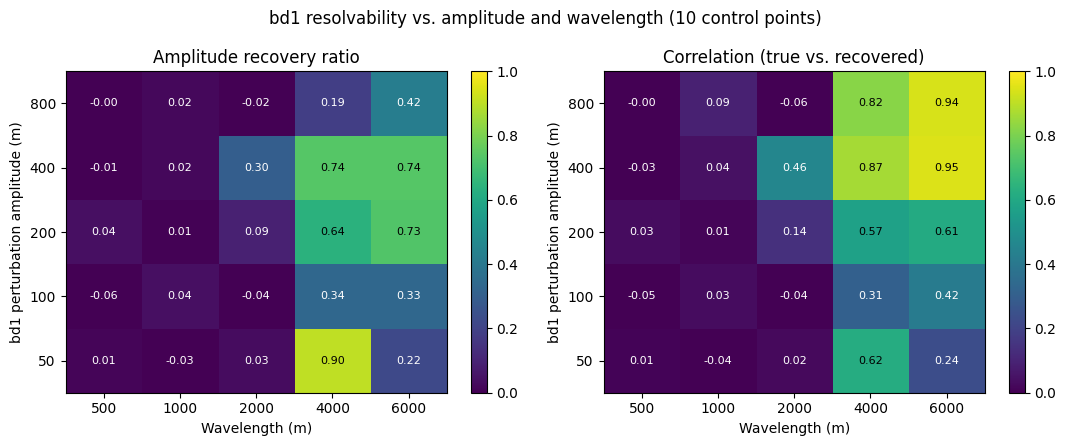

Saved amp_wavelength_map.png

=== (B) Bulk/DC-shift recovery test, field=bd1 ===
true_shift=  10 m  recovered=   8.04 +/- 21.28 m  (n=10)
true_shift=  25 m  recovered=  30.42 +/- 19.23 m  (n=10)
true_shift=  50 m  recovered=  48.34 +/- 15.39 m  (n=10)
true_shift= 100 m  recovered=  93.32 +/- 11.20 m  (n=10)
true_shift= 150 m  recovered= 145.77 +/- 13.38 m  (n=10)
true_shift= 190 m  recovered= 191.14 +/- 14.97 m  (n=10)
true_shift=   0 m  recovered=   5.22 +/- 15.42 m  (n=10)  <- noise floor


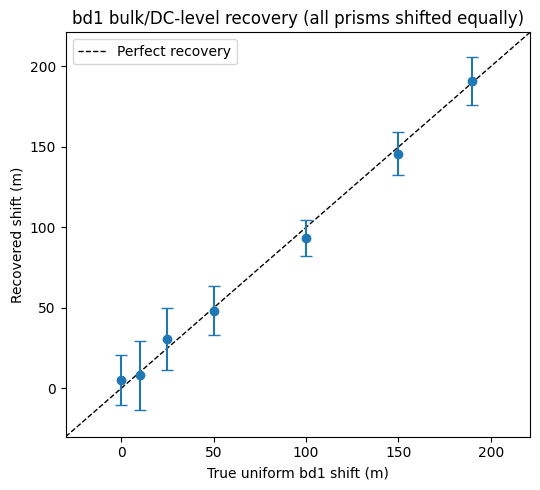

Saved bulk_shift_recovery.png


In [ ]:


import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# Reuses everything from the main script -- if you already ran
# checkerboard_resolution_test.py in this same notebook/session, you can
# delete this import line and just use those names directly.


PERTURB_FIELD = "bd1"   # kept fixed at bd1 for both follow-ups; change if testing bd2


# ======================================================================
# (A) AMPLITUDE x WAVELENGTH RESOLUTION MAP
# ======================================================================

AMPLITUDES_M = [50, 100, 200, 400, 800]     # m -- last two approach/exceed the ~200 m
                                             # min layer-2 thickness (bd2-bd1) at prism
                                             # index 6, so a sinusoid can locally push bd1
                                             # past bd2 there; treat those rows as
                                             # exploratory, not clean, for that reason
                                             # (see the DC-shift test below for the same issue)
WAVELENGTHS_M_A = [500, 1000, 2000, 4000,6000]   # m -- coarser than the main sweep, to keep runtime down
N_CTRL_A = 10                                # single representative control-point count
N_REPEATS_A = 4
PRIOR_STD_SCALE = 3.0                        # PRIOR_STD = PRIOR_STD_SCALE * amplitude, per point


def invert_bd1_perturbation(d_obs, ctrl_x, prior_std):
    """Same MAP machinery as the main script, factored out so both follow-up
    tests can call it with different amplitude-dependent PRIOR_STD."""
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        bd1 = BD1_BG + pert_field
        if np.any(bd1 <= 0) or np.any(BD2_BG <= bd1):
            return np.full(len(X_OBS) + n_ctrl, 1e3)
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, BD2_BG, TD, DEN1_BG, DEN2_BG)
        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = ctrl_pert / prior_std
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * max(prior_std / PRIOR_STD_SCALE, 1.0)
    result = least_squares(residuals, x0, method="trf", bounds=(-bound, bound),
                            xtol=1e-10, ftol=1e-10)
    return controls_to_field(result.x, ctrl_x)


def run_amplitude_wavelength_map():
    rng = np.random.default_rng(RANDOM_SEED + 1)
    ctrl_x = make_control_grid(N_CTRL_A)

    amp_ratio_grid = np.zeros((len(AMPLITUDES_M), len(WAVELENGTHS_M_A)))
    corr_grid = np.zeros_like(amp_ratio_grid)

    for ia, amp in enumerate(AMPLITUDES_M):
        prior_std = PRIOR_STD_SCALE * amp
        for iw, wavelength in enumerate(WAVELENGTHS_M_A):
            true_pert = amp * np.sin(2.0 * np.pi * CO / wavelength)
            bd1_true = BD1_BG + true_pert
            clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1_true, BD2_BG,
                                               TD, DEN1_BG, DEN2_BG)

            amp_ratios, corrs = [], []
            for _ in range(N_REPEATS_A):
                noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise
                recovered_pert = invert_bd1_perturbation(d_obs, ctrl_x, prior_std)
                ar, cr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(ar)
                corrs.append(cr)

            amp_ratio_grid[ia, iw] = np.mean(amp_ratios)
            corr_grid[ia, iw] = np.mean(corrs)
            print(f"amp={amp:4d} m  wavelength={wavelength:5d} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}  corr={np.mean(corrs):5.2f}")

    return amp_ratio_grid, corr_grid


def plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid, save_path="amp_wavelength_map.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, grid, title in [(axes[0], amp_ratio_grid, "Amplitude recovery ratio"),
                             (axes[1], corr_grid, "Correlation (true vs. recovered)")]:
        im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1,
                        extent=[0, len(WAVELENGTHS_M_A), 0, len(AMPLITUDES_M)])
        ax.set_xticks(np.arange(len(WAVELENGTHS_M_A)) + 0.5)
        ax.set_xticklabels(WAVELENGTHS_M_A)
        ax.set_yticks(np.arange(len(AMPLITUDES_M)) + 0.5)
        ax.set_yticklabels(AMPLITUDES_M)
        ax.set_xlabel("Wavelength (m)")
        ax.set_ylabel("bd1 perturbation amplitude (m)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
        for ia in range(len(AMPLITUDES_M)):
            for iw in range(len(WAVELENGTHS_M_A)):
                ax.text(iw + 0.5, ia + 0.5, f"{grid[ia, iw]:.2f}", ha="center", va="center",
                         color="white" if grid[ia, iw] < 0.5 else "black", fontsize=8)
    fig.suptitle(f"bd1 resolvability vs. amplitude and wavelength ({N_CTRL_A} control points)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# (B) BULK / DC-SHIFT RECOVERABILITY TEST
# =====================================================================
SHIFT_MAGNITUDES_M = [10, 25, 50, 100, 150, 190]

N_REPEATS_B = 10
SHIFT_PRIOR_STD = 1000.0   # very wide -- a bulk shift is a single number, let the data speak


def invert_bulk_shift(d_obs):
    """Fit a single scalar uniform shift to bd1 (the n_ctrl=1 / infinite-
    wavelength limit of the reduced basis)."""
    def residuals(shift):
        bd1 = BD1_BG + shift[0]
        if np.any(bd1 <= 0) or np.any(BD2_BG <= bd1):
            return np.full(len(X_OBS) + 1, 1e3)
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, BD2_BG, TD, DEN1_BG, DEN2_BG)
        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = np.array([shift[0] / SHIFT_PRIOR_STD])
        return np.concatenate([data_resid, prior_resid])

    result = least_squares(residuals, x0=[0.0], method="trf",
                            bounds=(-3000, 3000), xtol=1e-12, ftol=1e-12)
    return result.x[0]


def run_bulk_shift_test():
    rng = np.random.default_rng(RANDOM_SEED + 2)
    records = []  # (true_shift, recovered_mean, recovered_std)

    for true_shift in SHIFT_MAGNITUDES_M:
        bd1_true = BD1_BG + true_shift
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1_true, BD2_BG,
                                           TD, DEN1_BG, DEN2_BG)
        recovered = []
        for _ in range(N_REPEATS_B):
            noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
            d_obs = clean_data + noise
            recovered.append(invert_bulk_shift(d_obs))
        recovered = np.array(recovered)
        records.append((true_shift, recovered.mean(), recovered.std()))
        print(f"true_shift={true_shift:4d} m  recovered={recovered.mean():7.2f} "
              f"+/- {recovered.std():5.2f} m  (n={N_REPEATS_B})")

    # also run a true_shift=0 control, to see the noise floor of the shift estimate
    bd1_true = BD1_BG.copy()
    clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1_true, BD2_BG, TD, DEN1_BG, DEN2_BG)
    recovered0 = []
    for _ in range(N_REPEATS_B):
        noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
        d_obs = clean_data + noise
        recovered0.append(invert_bulk_shift(d_obs))
    recovered0 = np.array(recovered0)
    print(f"true_shift=   0 m  recovered={recovered0.mean():7.2f} "
          f"+/- {recovered0.std():5.2f} m  (n={N_REPEATS_B})  <- noise floor")

    return records, (0.0, recovered0.mean(), recovered0.std())


def plot_bulk_shift_test(records, zero_record, save_path="bulk_shift_recovery.png"):
    true_shifts = np.array([0.0] + [r[0] for r in records])
    recovered_means = np.array([zero_record[1]] + [r[1] for r in records])
    recovered_stds = np.array([zero_record[2]] + [r[2] for r in records])

    fig, ax = plt.subplots(figsize=(5.5, 5))
    lims = [min(true_shifts.min(), recovered_means.min()) - 30,
            max(true_shifts.max(), recovered_means.max()) + 30]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect recovery")
    ax.errorbar(true_shifts, recovered_means, yerr=recovered_stds, fmt="o", capsize=4,
                color="tab:blue")
    ax.set_xlabel("True uniform bd1 shift (m)")
    ax.set_ylabel("Recovered shift (m)")
    ax.set_title("bd1 bulk/DC-level recovery (all prisms shifted equally)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# RUN
# ======================================================================

if __name__ == "__main__":
    print("=== (A) Amplitude x wavelength map, field=bd1 ===")
    amp_ratio_grid, corr_grid = run_amplitude_wavelength_map()
    plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid)

    print("\n=== (B) Bulk/DC-shift recovery test, field=bd1 ===")
    records, zero_record = run_bulk_shift_test()
    plot_bulk_shift_test(records, zero_record)

field=bd2    n_ctrl= 5  wavelength=  250 m  amp_ratio= 0.08+/-0.05  corr= 0.08+/-0.05  (n=6)
field=bd2    n_ctrl=10  wavelength=  250 m  amp_ratio=-0.03+/-0.09  corr=-0.01+/-0.10  (n=6)
field=bd2    n_ctrl=15  wavelength=  250 m  amp_ratio=-0.05+/-0.06  corr=-0.08+/-0.08  (n=6)
field=bd2    n_ctrl=20  wavelength=  250 m  amp_ratio= 0.04+/-0.12  corr= 0.01+/-0.16  (n=6)
field=bd2    n_ctrl= 5  wavelength=  350 m  amp_ratio=-0.05+/-0.07  corr=-0.04+/-0.08  (n=6)
field=bd2    n_ctrl=10  wavelength=  350 m  amp_ratio=-0.03+/-0.07  corr=-0.01+/-0.11  (n=6)
field=bd2    n_ctrl=15  wavelength=  350 m  amp_ratio=-0.00+/-0.17  corr= 0.01+/-0.16  (n=6)
field=bd2    n_ctrl=20  wavelength=  350 m  amp_ratio= 0.04+/-0.05  corr= 0.07+/-0.08  (n=6)
field=bd2    n_ctrl= 5  wavelength=  500 m  amp_ratio= 0.02+/-0.06  corr= 0.01+/-0.06  (n=6)
field=bd2    n_ctrl=10  wavelength=  500 m  amp_ratio= 0.01+/-0.05  corr= 0.00+/-0.05  (n=6)
field=bd2    n_ctrl=15  wavelength=  500 m  amp_ratio=-0.01+/-0.03  co

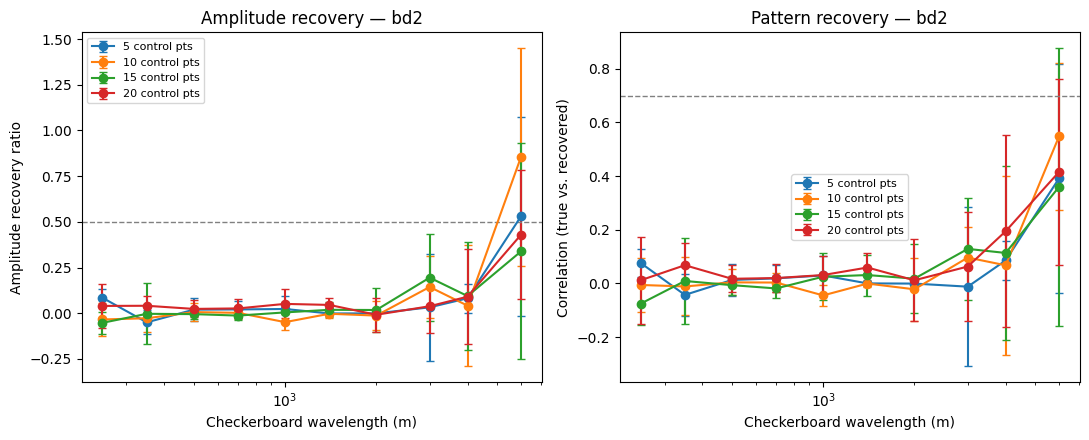

Saved resolution-curve figure to resolution_curves.png


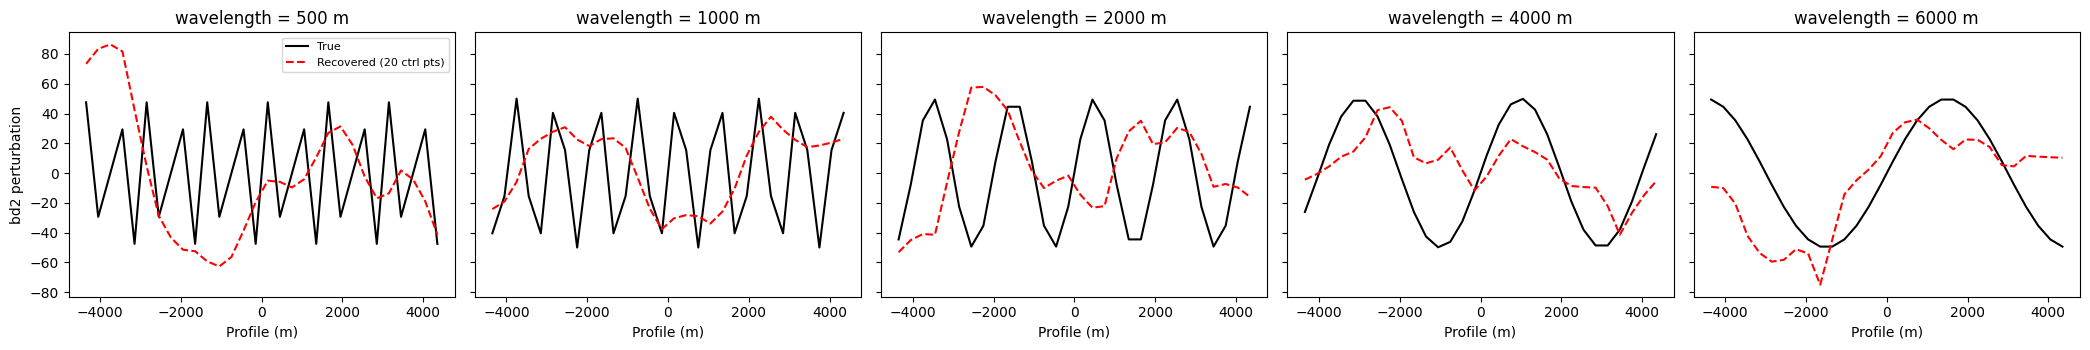

Saved example-recovery figure to example_recovery.png


In [ ]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ======================================================================
# 1. YOUR FORWARD MODEL -- copied verbatim, not modified
# ======================================================================

def g_anomaly(x, A, m, D, d, rho):
    G = 6.67 * (10 ** -6)
    r1 = (((x - A) + (0.5 * m)) ** 2) + ((d) ** 2)
    r2 = (((x - A) + (0.5 * m)) ** 2) + ((D) ** 2)
    r3 = (((x - A) - (0.5 * m)) ** 2) + ((d) ** 2)
    r4 = (((x - A) - (0.5 * m)) ** 2) + ((D) ** 2)
    f1 = np.arctan((x - A + (0.5 * m)) / (D)) - np.arctan((x - A - (0.5 * m)) / (D))
    f2 = np.arctan((x - A + (0.5 * m)) / d) - np.arctan((x - A - (0.5 * m)) / d)
    f3 = 0.5 * (x - A) * (np.log10((r2 * r3) / (r1 * r4)))
    f4 = 0.25 * m * (np.log10((r2 * r4) / (r1 * r3)))
    f = ((D) * f1) - (d * f2) + f3 + f4
    g = 2 * G * rho * f  # in milligal
    return g


def g_n_anomaly(N, x, A, m, D, d, rho):
    u = 0
    for i in range(N):
        v = g_anomaly(x, A[i], m[i], D[i], d[i], rho[i])
        u = u + v
    return u


def measure_func_general(x, n, co, wid, bd1, bd2, td, den1, den2):
    """Your measure_func, generalized to take bd1/bd2/den1/den2 as arguments
    instead of closing over module-level globals, so the inversion can pass
    in trial models."""
    return (g_n_anomaly(n, x, co, wid, bd1, td, den1)
            + g_n_anomaly(n, x, co, wid, bd2, bd1, den2))


# ======================================================================
# 2. USER-EDITABLE SETTINGS
# ======================================================================

N_PRISM = 30
CO = np.linspace(-4350, 4350, N_PRISM)          # prism centers
WID = np.full(N_PRISM, 300.0)                   # prism widths
TD = np.full(N_PRISM, 1e-6)                     # top of layer 1 (~surface, fixed, never perturbed)
BD1_BG = np.array([500, 510, 520, 530, 540, 545, 550, 545, 540, 530, 520, 490, 470,
                    460, 450, 440, 420, 410, 400, 390, 385, 380, 385, 390, 400, 410,
                    420, 430, 460, 470], dtype=float)
BD2_BG = np.array([800, 790, 780, 770, 760, 755, 750, 755, 760, 770, 780, 810, 830,
                    840, 850, 860, 880, 890, 900, 910, 915, 920, 915, 910, 900, 890,
                    880, 870, 850, 830], dtype=float)
DEN1_BG = np.array([-100 - i * 3 for i in range(N_PRISM)], dtype=float)
DEN2_BG = np.array([-220 - i * 2 for i in range(N_PRISM)], dtype=float)

# --- observation stations (matches your X = np.linspace(-5000,5000,50)) ---
N_OBS = 50
X_OBS = np.linspace(-5000, 5000, N_OBS)

# --- which field to run the resolution test on ---
# one of: "bd1", "bd2", "den1", "den2"
PERTURB_FIELD = "bd2"
PERTURB_AMPLITUDE = 50.0           # m for bd1/bd2, kg/m^3 for den1/den2


NOISE_STD_MGAL = 0.5
USE_COMPOUND_NOISE = False

# --- control-point densities and wavelengths to sweep ---
N_CTRL_LIST = [5, 10, 15, 20]
WAVELENGTHS_M = [250, 350, 500, 700, 1000, 1400, 2000, 3000, 4000,6000]

# --- noise realizations per (wavelength, n_ctrl) point ---
N_REPEATS = 6

# --- weak Gaussian prior on each control point (std, same units as
# PERTURB_AMPLITUDE). Turns the inversion into a genuine MAP estimate rather
# than unregularized least squares -- keep this wide relative to
# PERTURB_AMPLITUDE so you're testing data resolution, not prior strength. ---
PRIOR_STD = 3.0 * PERTURB_AMPLITUDE

# --- recovery thresholds that define "resolved" ---
AMP_RATIO_THRESHOLD = 0.5
CORR_THRESHOLD = 0.7

# --- optimizer / misc ---
RANDOM_SEED = 20260828


def make_compound_noise(rng, x_shape):
    """Reproduces your notebook's compound noise generator (Gaussian +
    random-walk + salt&pepper + systematic), for use if USE_COMPOUND_NOISE=True."""
    gaussian_noise = rng.normal(0, 0.3, size=x_shape)
    random_steps = rng.normal(0, 0.1, size=x_shape)
    random_walk_noise = np.cumsum(random_steps)
    salt_prob, pepper_prob, noise_level = 0.05, 0.05, 0.05
    salt_and_pepper_noise = rng.choice(
        [0, 1, -1], size=x_shape, p=[1 - (salt_prob + pepper_prob), salt_prob, pepper_prob]
    ) * noise_level
    a, b, c = 0.001, 0.0001, 0.001
    systematic_noise_level = 0.05
    systematic_noise = systematic_noise_level * (
        (a * ((X_OBS * 0.01) ** 2)) + (b * ((X_OBS * 0.01) ** 3)) + c
    )
    return gaussian_noise + random_walk_noise + salt_and_pepper_noise + systematic_noise


# ======================================================================
# 3. REDUCED-BASIS (PIECEWISE-LINEAR CONTROL-POINT) PARAMETERIZATION
# ======================================================================

def make_control_grid(n_ctrl):
    return np.linspace(CO.min(), CO.max(), n_ctrl)


def controls_to_field(ctrl_values, ctrl_x, prism_x=CO):
    """Piecewise-linear interpolation from control points to full prism
    resolution -- matches the reduced-basis parameterization in 3.3.5."""
    return np.interp(prism_x, ctrl_x, ctrl_values)


# ======================================================================
# 4. CHECKERBOARD (SINUSOIDAL) SYNTHETIC MODEL
# ======================================================================

def build_true_field(field_name, wavelength, amplitude):
    bd1 = BD1_BG.copy()
    bd2 = BD2_BG.copy()
    den1 = DEN1_BG.copy()
    den2 = DEN2_BG.copy()

    perturbation = amplitude * np.sin(2.0 * np.pi * CO / wavelength)
    if field_name == "bd1":
        bd1 = bd1 + perturbation
    elif field_name == "bd2":
        bd2 = bd2 + perturbation
    elif field_name == "den1":
        den1 = den1 + perturbation
    elif field_name == "den2":
        den2 = den2 + perturbation
    else:
        raise ValueError(f"Unknown PERTURB_FIELD: {field_name}")

    if np.any(bd1 >= bd2):
        raise ValueError("Perturbation makes bd1 >= bd2 somewhere -- reduce "
                          "PERTURB_AMPLITUDE or check the field being perturbed.")

    return bd1, bd2, den1, den2, perturbation


# ======================================================================
# 5. MAP INVERSION (control points -> best fit to synthetic data)
# ======================================================================

def invert_control_points(d_obs, noise_std, ctrl_x, field_name):
    """
    Fit control-point values for `field_name` (others fixed at background) by
    minimizing [data misfit] + [weak Gaussian prior], via
    scipy.optimize.least_squares with a finite-difference Jacobian (your
    forward model isn't auto-differentiable).
    """
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)  # optimize the PERTURBATION around background

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        bd1, bd2, den1, den2 = BD1_BG.copy(), BD2_BG.copy(), DEN1_BG.copy(), DEN2_BG.copy()
        if field_name == "bd1":
            bd1 = bd1 + pert_field
        elif field_name == "bd2":
            bd2 = bd2 + pert_field
        elif field_name == "den1":
            den1 = den1 + pert_field
        elif field_name == "den2":
            den2 = den2 + pert_field

        # keep the forward model well-defined even if the optimizer proposes
        # a physically invalid crossing mid-search; penalize instead of crashing
        if np.any(bd1 <= 0) or np.any(bd2 <= bd1):
            return np.full(len(X_OBS) + n_ctrl, 1e3)

        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)
        data_resid = (pred - d_obs) / noise_std
        prior_resid = ctrl_pert / PRIOR_STD
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * PERTURB_AMPLITUDE
    result = least_squares(residuals, x0, method="trf",
                            bounds=(-bound, bound), xtol=1e-10, ftol=1e-10)

    recovered_pert = controls_to_field(result.x, ctrl_x)
    return recovered_pert


# ======================================================================
# 6. RECOVERY METRICS
# ======================================================================

def recovery_metrics(true_pert, recovered_pert):
    """
    amp_ratio: best-fit scalar (least-squares projection of recovered onto
               true) -- 1.0 = full amplitude recovered, 0.0 = smoothed away.
    corr:      Pearson correlation -- checks the pattern/phase was recovered.
    """
    denom = np.sum(true_pert ** 2)
    amp_ratio = float(np.sum(recovered_pert * true_pert) / denom) if denom > 0 else np.nan
    if np.std(true_pert) > 0 and np.std(recovered_pert) > 0:
        corr = float(np.corrcoef(true_pert, recovered_pert)[0, 1])
    else:
        corr = np.nan
    return amp_ratio, corr


# ======================================================================
# 7. MAIN SWEEP
# ======================================================================

def run_resolution_sweep():
    rng = np.random.default_rng(RANDOM_SEED)

    results = {n_ctrl: {"wavelength": [], "amp_ratio_mean": [], "amp_ratio_std": [],
                         "corr_mean": [], "corr_std": []} for n_ctrl in N_CTRL_LIST}
    example_cache = {}

    for wavelength in WAVELENGTHS_M:
        bd1, bd2, den1, den2, true_pert = build_true_field(PERTURB_FIELD, wavelength, PERTURB_AMPLITUDE)
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)

        for n_ctrl in N_CTRL_LIST:
            ctrl_x = make_control_grid(n_ctrl)
            amp_ratios, corrs = [], []

            for rep in range(N_REPEATS):
                if USE_COMPOUND_NOISE:
                    noise = make_compound_noise(rng, X_OBS.shape)
                else:
                    noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise

                recovered_pert = invert_control_points(d_obs, NOISE_STD_MGAL, ctrl_x, PERTURB_FIELD)
                amp_ratio, corr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(amp_ratio)
                corrs.append(corr)

                if rep == 0 and n_ctrl == 20 and wavelength in (500, 1000, 2000, 4000,6000):
                    example_cache[wavelength] = (true_pert.copy(), recovered_pert.copy())

            results[n_ctrl]["wavelength"].append(wavelength)
            results[n_ctrl]["amp_ratio_mean"].append(float(np.mean(amp_ratios)))
            results[n_ctrl]["amp_ratio_std"].append(float(np.std(amp_ratios)))
            results[n_ctrl]["corr_mean"].append(float(np.mean(corrs)))
            results[n_ctrl]["corr_std"].append(float(np.std(corrs)))

            print(f"field={PERTURB_FIELD:5s}  n_ctrl={n_ctrl:2d}  wavelength={wavelength:5.0f} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}+/-{np.std(amp_ratios):.2f}  "
                  f"corr={np.mean(corrs):5.2f}+/-{np.std(corrs):.2f}  (n={N_REPEATS})")

    return results, example_cache


def shortest_recoverable_wavelength(results):
    summary = {}
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        amp = np.array(r["amp_ratio_mean"])
        corr = np.array(r["corr_mean"])
        order = np.argsort(wl)
        wl, amp, corr = wl[order], amp[order], corr[order]
        ok = (amp >= AMP_RATIO_THRESHOLD) & (corr >= CORR_THRESHOLD)
        summary[n_ctrl] = float(wl[ok][0]) if ok.any() else float("nan")
    return summary


# ======================================================================
# 8. PLOTTING
# ======================================================================

def plot_resolution_curves(results, save_path="resolution_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        order = np.argsort(wl)
        axes[0].errorbar(wl[order], np.array(r["amp_ratio_mean"])[order],
                          yerr=np.array(r["amp_ratio_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")
        axes[1].errorbar(wl[order], np.array(r["corr_mean"])[order],
                          yerr=np.array(r["corr_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")

    axes[0].axhline(AMP_RATIO_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Checkerboard wavelength (m)")
    axes[0].set_ylabel("Amplitude recovery ratio")
    axes[0].set_title(f"Amplitude recovery — {PERTURB_FIELD}")
    axes[0].set_xscale("log")
    axes[0].legend(fontsize=8)

    axes[1].axhline(CORR_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Checkerboard wavelength (m)")
    axes[1].set_ylabel("Correlation (true vs. recovered)")
    axes[1].set_title(f"Pattern recovery — {PERTURB_FIELD}")
    axes[1].set_xscale("log")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved resolution-curve figure to {save_path}")


def plot_example_recovery(example_cache, save_path="example_recovery.png"):
    n = len(example_cache)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, (wavelength, (true_pert, recovered_pert)) in zip(axes, sorted(example_cache.items())):
        ax.plot(CO, true_pert, "k-", label="True")
        ax.plot(CO, recovered_pert, "r--", label="Recovered (20 ctrl pts)")
        ax.set_title(f"wavelength = {wavelength} m")
        ax.set_xlabel("Profile (m)")
    axes[0].set_ylabel(f"{PERTURB_FIELD} perturbation")
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved example-recovery figure to {save_path}")


# ======================================================================
# 9. RUN
# ======================================================================

if __name__ == "__main__":
    results, example_cache = run_resolution_sweep()
    summary = shortest_recoverable_wavelength(results)

    print("\nShortest recoverable wavelength per control-point density "
          f"(amp_ratio >= {AMP_RATIO_THRESHOLD}, corr >= {CORR_THRESHOLD}):")
    for n_ctrl in N_CTRL_LIST:
        wl = summary[n_ctrl]
        print(f"  {n_ctrl:2d} control points -> {wl:.0f} m" if not np.isnan(wl)
              else f"  {n_ctrl:2d} control points -> not resolved in tested range")

    plot_resolution_curves(results)
    plot_example_recovery(example_cache)

=== (A) Amplitude x wavelength map, field=bd2 ===
amp=  50 m  wavelength=  500 m  amp_ratio=-0.00  corr=-0.01
amp=  50 m  wavelength= 1000 m  amp_ratio= 0.03  corr= 0.04
amp=  50 m  wavelength= 2000 m  amp_ratio= 0.04  corr= 0.06
amp=  50 m  wavelength= 4000 m  amp_ratio=-0.19  corr=-0.16
amp=  50 m  wavelength= 6000 m  amp_ratio= 0.82  corr= 0.72
amp= 100 m  wavelength=  500 m  amp_ratio= 0.09  corr= 0.08
amp= 100 m  wavelength= 1000 m  amp_ratio=-0.02  corr=-0.01
amp= 100 m  wavelength= 2000 m  amp_ratio= 0.07  corr= 0.11
amp= 100 m  wavelength= 4000 m  amp_ratio= 0.50  corr= 0.34
amp= 100 m  wavelength= 6000 m  amp_ratio= 1.23  corr= 0.88
amp= 200 m  wavelength=  500 m  amp_ratio=-0.01  corr=-0.01
amp= 200 m  wavelength= 1000 m  amp_ratio=-0.00  corr=-0.01
amp= 200 m  wavelength= 2000 m  amp_ratio= 0.04  corr= 0.09
amp= 200 m  wavelength= 4000 m  amp_ratio= 0.62  corr= 0.62
amp= 200 m  wavelength= 6000 m  amp_ratio= 0.86  corr= 0.91
amp= 400 m  wavelength=  500 m  amp_ratio= 0.04  c

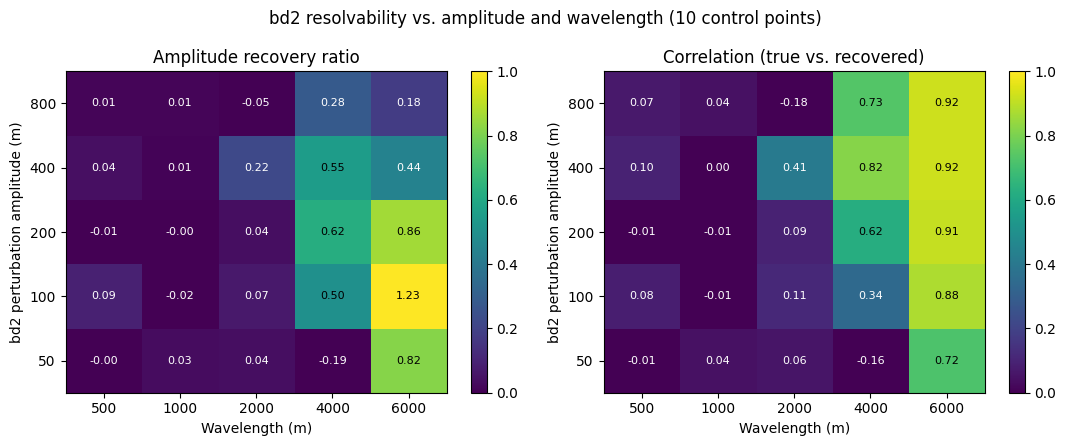

Saved amp_wavelength_map.png

=== (B) Bulk/DC-shift recovery test, field=bd2 ===
true_shift=  10 m  recovered=  11.12 +/- 10.09 m  (n=10)
true_shift=  25 m  recovered=  22.13 +/-  8.75 m  (n=10)
true_shift=  50 m  recovered=  50.80 +/-  7.25 m  (n=10)
true_shift= 100 m  recovered= 103.24 +/-  4.93 m  (n=10)
true_shift= 150 m  recovered= 151.80 +/-  6.39 m  (n=10)
true_shift= 190 m  recovered= 186.12 +/- 11.37 m  (n=10)
true_shift= 300 m  recovered= 297.30 +/-  8.45 m  (n=10)
true_shift= 500 m  recovered= 503.70 +/-  5.84 m  (n=10)
true_shift=   0 m  recovered=   0.79 +/-  8.70 m  (n=10)  <- noise floor


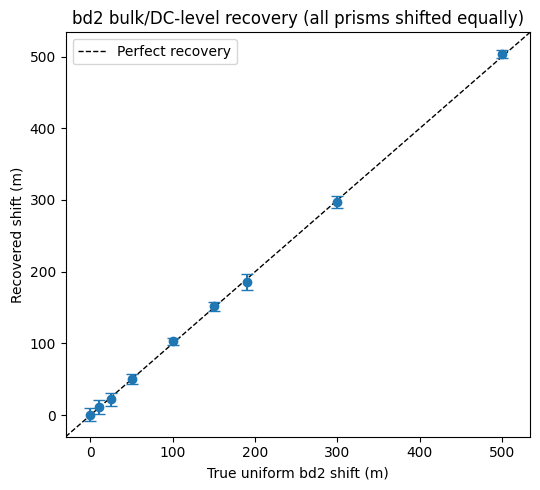

Saved bulk_shift_recovery.png


In [ ]:

import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt


PERTURB_FIELD = "bd2"   # Set to bd2


# ======================================================================
# (A) AMPLITUDE x WAVELENGTH RESOLUTION MAP
# ======================================================================

AMPLITUDES_M = [50, 100, 200, 400, 800]
WAVELENGTHS_M_A = [500, 1000, 2000, 4000,6000]
N_CTRL_A = 10
N_REPEATS_A = 4
PRIOR_STD_SCALE = 3.0


def invert_bd2_perturbation(d_obs, ctrl_x, prior_std):
    """Same MAP machinery as the main script, factored out so both follow-up
    tests can call it with different amplitude-dependent PRIOR_STD."""
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        bd2 = BD2_BG + pert_field

        # Check boundary intersection (bd2 must remain below bd1)
        if np.any(bd2 <= BD1_BG):
            return np.full(len(X_OBS) + n_ctrl, 1e3)

        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, bd2, TD, DEN1_BG, DEN2_BG)
        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = ctrl_pert / prior_std
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * max(prior_std / PRIOR_STD_SCALE, 1.0)
    result = least_squares(residuals, x0, method="trf", bounds=(-bound, bound),
                            xtol=1e-10, ftol=1e-10)
    return controls_to_field(result.x, ctrl_x)


def run_amplitude_wavelength_map():
    rng = np.random.default_rng(RANDOM_SEED + 1)
    ctrl_x = make_control_grid(N_CTRL_A)

    amp_ratio_grid = np.zeros((len(AMPLITUDES_M), len(WAVELENGTHS_M_A)))
    corr_grid = np.zeros_like(amp_ratio_grid)

    for ia, amp in enumerate(AMPLITUDES_M):
        prior_std = PRIOR_STD_SCALE * amp
        for iw, wavelength in enumerate(WAVELENGTHS_M_A):
            true_pert = amp * np.sin(2.0 * np.pi * CO / wavelength)
            bd2_true = BD2_BG + true_pert
            clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, bd2_true,
                                               TD, DEN1_BG, DEN2_BG)

            amp_ratios, corrs = [], []
            for _ in range(N_REPEATS_A):
                noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise
                recovered_pert = invert_bd2_perturbation(d_obs, ctrl_x, prior_std)
                ar, cr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(ar)
                corrs.append(cr)

            amp_ratio_grid[ia, iw] = np.mean(amp_ratios)
            corr_grid[ia, iw] = np.mean(corrs)
            print(f"amp={amp:4d} m  wavelength={wavelength:5d} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}  corr={np.mean(corrs):5.2f}")

    return amp_ratio_grid, corr_grid


def plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid, save_path="amp_wavelength_map.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, grid, title in [(axes[0], amp_ratio_grid, "Amplitude recovery ratio"),
                             (axes[1], corr_grid, "Correlation (true vs. recovered)")]:
        im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1,
                        extent=[0, len(WAVELENGTHS_M_A), 0, len(AMPLITUDES_M)])
        ax.set_xticks(np.arange(len(WAVELENGTHS_M_A)) + 0.5)
        ax.set_xticklabels(WAVELENGTHS_M_A)
        ax.set_yticks(np.arange(len(AMPLITUDES_M)) + 0.5)
        ax.set_yticklabels(AMPLITUDES_M)
        ax.set_xlabel("Wavelength (m)")
        ax.set_ylabel("bd2 perturbation amplitude (m)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
        for ia in range(len(AMPLITUDES_M)):
            for iw in range(len(WAVELENGTHS_M_A)):
                ax.text(iw + 0.5, ia + 0.5, f"{grid[ia, iw]:.2f}", ha="center", va="center",
                         color="white" if grid[ia, iw] < 0.5 else "black", fontsize=8)
    fig.suptitle(f"bd2 resolvability vs. amplitude and wavelength ({N_CTRL_A} control points)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# (B) BULK / DC-SHIFT RECOVERABILITY TEST
# ======================================================================

SHIFT_MAGNITUDES_M = [10, 25, 50, 100, 150, 190, 300, 500]
# NOTE: Moving bd2 deeper (positive shift) is not bounded by bd1. If you test
# negative shifts (making the layer shallower), it would be bounded by bd1.
N_REPEATS_B = 10
SHIFT_PRIOR_STD = 1000.0


def invert_bulk_shift(d_obs):
    """Fit a single scalar uniform shift to bd2"""
    def residuals(shift):
        bd2 = BD2_BG + shift[0]
        if np.any(bd2 <= BD1_BG):
            return np.full(len(X_OBS) + 1, 1e3)
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, bd2, TD, DEN1_BG, DEN2_BG)
        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = np.array([shift[0] / SHIFT_PRIOR_STD])
        return np.concatenate([data_resid, prior_resid])

    result = least_squares(residuals, x0=[0.0], method="trf",
                            bounds=(-3000, 3000), xtol=1e-12, ftol=1e-12)
    return result.x[0]


def run_bulk_shift_test():
    rng = np.random.default_rng(RANDOM_SEED + 2)
    records = []

    for true_shift in SHIFT_MAGNITUDES_M:
        bd2_true = BD2_BG + true_shift
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, bd2_true,
                                           TD, DEN1_BG, DEN2_BG)
        recovered = []
        for _ in range(N_REPEATS_B):
            noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
            d_obs = clean_data + noise
            recovered.append(invert_bulk_shift(d_obs))
        recovered = np.array(recovered)
        records.append((true_shift, recovered.mean(), recovered.std()))
        print(f"true_shift={true_shift:4d} m  recovered={recovered.mean():7.2f} "
              f"+/- {recovered.std():5.2f} m  (n={N_REPEATS_B})")

    # also run a true_shift=0 control
    bd2_true = BD2_BG.copy()
    clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, bd2_true, TD, DEN1_BG, DEN2_BG)
    recovered0 = []
    for _ in range(N_REPEATS_B):
        noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
        d_obs = clean_data + noise
        recovered0.append(invert_bulk_shift(d_obs))
    recovered0 = np.array(recovered0)
    print(f"true_shift=   0 m  recovered={recovered0.mean():7.2f} "
          f"+/- {recovered0.std():5.2f} m  (n={N_REPEATS_B})  <- noise floor")

    return records, (0.0, recovered0.mean(), recovered0.std())


def plot_bulk_shift_test(records, zero_record, save_path="bulk_shift_recovery.png"):
    true_shifts = np.array([0.0] + [r[0] for r in records])
    recovered_means = np.array([zero_record[1]] + [r[1] for r in records])
    recovered_stds = np.array([zero_record[2]] + [r[2] for r in records])

    fig, ax = plt.subplots(figsize=(5.5, 5))
    lims = [min(true_shifts.min(), recovered_means.min()) - 30,
            max(true_shifts.max(), recovered_means.max()) + 30]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect recovery")
    ax.errorbar(true_shifts, recovered_means, yerr=recovered_stds, fmt="o", capsize=4,
                color="tab:blue")
    ax.set_xlabel("True uniform bd2 shift (m)")
    ax.set_ylabel("Recovered shift (m)")
    ax.set_title("bd2 bulk/DC-level recovery (all prisms shifted equally)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# RUN
# ======================================================================

if __name__ == "__main__":
    print("=== (A) Amplitude x wavelength map, field=bd2 ===")
    amp_ratio_grid, corr_grid = run_amplitude_wavelength_map()
    plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid)

    print("\n=== (B) Bulk/DC-shift recovery test, field=bd2 ===")
    records, zero_record = run_bulk_shift_test()
    plot_bulk_shift_test(records, zero_record)

field=den1   n_ctrl= 5  wavelength=  250 m  amp_ratio= 0.02+/-0.02  corr= 0.04+/-0.04  (n=6)
field=den1   n_ctrl=10  wavelength=  250 m  amp_ratio= 0.16+/-0.15  corr= 0.20+/-0.17  (n=6)
field=den1   n_ctrl=15  wavelength=  250 m  amp_ratio= 0.47+/-0.22  corr= 0.42+/-0.18  (n=6)
field=den1   n_ctrl=20  wavelength=  250 m  amp_ratio= 0.74+/-0.21  corr= 0.56+/-0.14  (n=6)
field=den1   n_ctrl= 5  wavelength=  350 m  amp_ratio= 0.05+/-0.02  corr= 0.11+/-0.02  (n=6)
field=den1   n_ctrl=10  wavelength=  350 m  amp_ratio= 0.63+/-0.19  corr= 0.68+/-0.18  (n=6)
field=den1   n_ctrl=15  wavelength=  350 m  amp_ratio= 0.80+/-0.28  corr= 0.63+/-0.21  (n=6)
field=den1   n_ctrl=20  wavelength=  350 m  amp_ratio= 0.93+/-0.13  corr= 0.70+/-0.15  (n=6)
field=den1   n_ctrl= 5  wavelength=  500 m  amp_ratio= 0.01+/-0.02  corr= 0.02+/-0.06  (n=6)
field=den1   n_ctrl=10  wavelength=  500 m  amp_ratio= 0.02+/-0.04  corr= 0.03+/-0.06  (n=6)
field=den1   n_ctrl=15  wavelength=  500 m  amp_ratio= 0.04+/-0.04  co

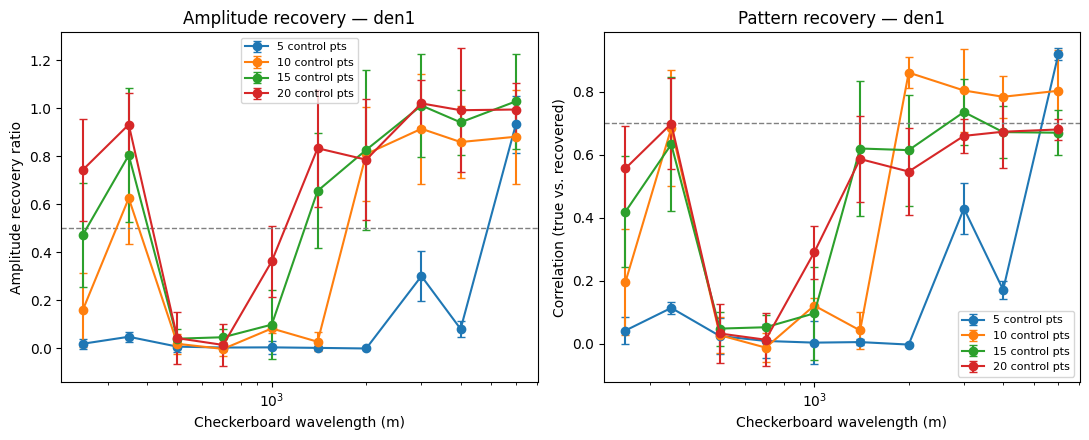

Saved resolution-curve figure to resolution_curves.png


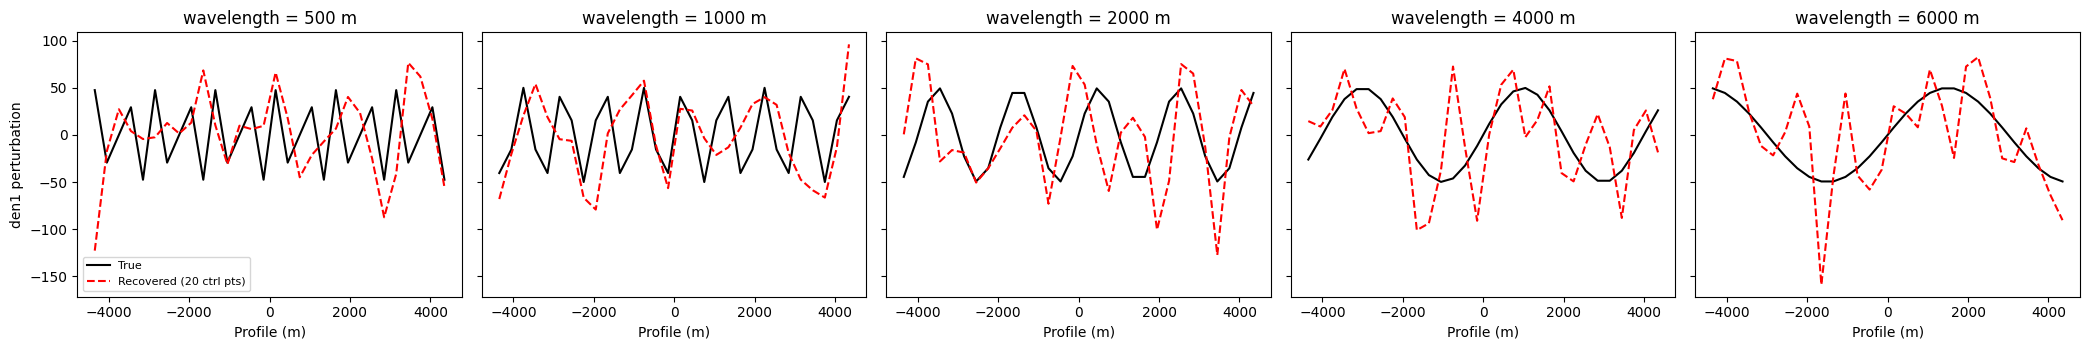

Saved example-recovery figure to example_recovery.png


In [ ]:


import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ======================================================================
# 1. YOUR FORWARD MODEL -- copied verbatim, not modified
# ======================================================================

def g_anomaly(x, A, m, D, d, rho):
    G = 6.67 * (10 ** -6)
    r1 = (((x - A) + (0.5 * m)) ** 2) + ((d) ** 2)
    r2 = (((x - A) + (0.5 * m)) ** 2) + ((D) ** 2)
    r3 = (((x - A) - (0.5 * m)) ** 2) + ((d) ** 2)
    r4 = (((x - A) - (0.5 * m)) ** 2) + ((D) ** 2)
    f1 = np.arctan((x - A + (0.5 * m)) / (D)) - np.arctan((x - A - (0.5 * m)) / (D))
    f2 = np.arctan((x - A + (0.5 * m)) / d) - np.arctan((x - A - (0.5 * m)) / d)
    f3 = 0.5 * (x - A) * (np.log10((r2 * r3) / (r1 * r4)))
    f4 = 0.25 * m * (np.log10((r2 * r4) / (r1 * r3)))
    f = ((D) * f1) - (d * f2) + f3 + f4
    g = 2 * G * rho * f  # in milligal
    return g


def g_n_anomaly(N, x, A, m, D, d, rho):
    u = 0
    for i in range(N):
        v = g_anomaly(x, A[i], m[i], D[i], d[i], rho[i])
        u = u + v
    return u


def measure_func_general(x, n, co, wid, bd1, bd2, td, den1, den2):
    """Your measure_func, generalized to take bd1/bd2/den1/den2 as arguments
    instead of closing over module-level globals, so the inversion can pass
    in trial models."""
    return (g_n_anomaly(n, x, co, wid, bd1, td, den1)
            + g_n_anomaly(n, x, co, wid, bd2, bd1, den2))

N_PRISM = 30
CO = np.linspace(-4350, 4350, N_PRISM)          # prism centers
WID = np.full(N_PRISM, 300.0)                   # prism widths
TD = np.full(N_PRISM, 1e-6)                     # top of layer 1 (~surface, fixed, never perturbed)
BD1_BG = np.array([500, 510, 520, 530, 540, 545, 550, 545, 540, 530, 520, 490, 470,
                    460, 450, 440, 420, 410, 400, 390, 385, 380, 385, 390, 400, 410,
                    420, 430, 460, 470], dtype=float)
BD2_BG = np.array([800, 790, 780, 770, 760, 755, 750, 755, 760, 770, 780, 810, 830,
                    840, 850, 860, 880, 890, 900, 910, 915, 920, 915, 910, 900, 890,
                    880, 870, 850, 830], dtype=float)
DEN1_BG = np.array([-100 - i * 3 for i in range(N_PRISM)], dtype=float)
DEN2_BG = np.array([-220 - i * 2 for i in range(N_PRISM)], dtype=float)

# --- observation stations (matches your X = np.linspace(-5000,5000,50)) ---
N_OBS = 50
X_OBS = np.linspace(-5000, 5000, N_OBS)

# --- which field to run the resolution test on ---
# one of: "bd1", "bd2", "den1", "den2"
PERTURB_FIELD = "den1"
PERTURB_AMPLITUDE = 50           # m for bd1/bd2, kg/m^3 for den1/den2

NOISE_STD_MGAL = 0.5
USE_COMPOUND_NOISE = False

# --- control-point densities and wavelengths to sweep ---
N_CTRL_LIST = [5, 10, 15, 20]
WAVELENGTHS_M = [250, 350, 500, 700, 1000, 1400, 2000, 3000, 4000,6000]

# --- noise realizations per (wavelength, n_ctrl) point ---
N_REPEATS = 6

# --- weak Gaussian prior on each control point (std, same units as
# PERTURB_AMPLITUDE). Turns the inversion into a genuine MAP estimate rather
# than unregularized least squares -- keep this wide relative to
# PERTURB_AMPLITUDE so you're testing data resolution, not prior strength. ---
PRIOR_STD = 3.0 * PERTURB_AMPLITUDE

# --- recovery thresholds that define "resolved" ---
AMP_RATIO_THRESHOLD = 0.5
CORR_THRESHOLD = 0.7

# --- optimizer / misc ---
RANDOM_SEED = 20260828


def make_compound_noise(rng, x_shape):
    """Reproduces your notebook's compound noise generator (Gaussian +
    random-walk + salt&pepper + systematic), for use if USE_COMPOUND_NOISE=True."""
    gaussian_noise = rng.normal(0, 0.3, size=x_shape)
    random_steps = rng.normal(0, 0.1, size=x_shape)
    random_walk_noise = np.cumsum(random_steps)
    salt_prob, pepper_prob, noise_level = 0.05, 0.05, 0.05
    salt_and_pepper_noise = rng.choice(
        [0, 1, -1], size=x_shape, p=[1 - (salt_prob + pepper_prob), salt_prob, pepper_prob]
    ) * noise_level
    a, b, c = 0.001, 0.0001, 0.001
    systematic_noise_level = 0.05
    systematic_noise = systematic_noise_level * (
        (a * ((X_OBS * 0.01) ** 2)) + (b * ((X_OBS * 0.01) ** 3)) + c
    )
    return gaussian_noise + random_walk_noise + salt_and_pepper_noise + systematic_noise


# ======================================================================
# 3. REDUCED-BASIS (PIECEWISE-LINEAR CONTROL-POINT) PARAMETERIZATION
# ======================================================================

def make_control_grid(n_ctrl):
    return np.linspace(CO.min(), CO.max(), n_ctrl)


def controls_to_field(ctrl_values, ctrl_x, prism_x=CO):
    """Piecewise-linear interpolation from control points to full prism
    resolution -- matches the reduced-basis parameterization in 3.3.5."""
    return np.interp(prism_x, ctrl_x, ctrl_values)


# ======================================================================
# 4. CHECKERBOARD (SINUSOIDAL) SYNTHETIC MODEL
# ======================================================================

def build_true_field(field_name, wavelength, amplitude):
    bd1 = BD1_BG.copy()
    bd2 = BD2_BG.copy()
    den1 = DEN1_BG.copy()
    den2 = DEN2_BG.copy()

    perturbation = amplitude * np.sin(2.0 * np.pi * CO / wavelength)
    if field_name == "bd1":
        bd1 = bd1 + perturbation
    elif field_name == "bd2":
        bd2 = bd2 + perturbation
    elif field_name == "den1":
        den1 = den1 + perturbation
    elif field_name == "den2":
        den2 = den2 + perturbation
    else:
        raise ValueError(f"Unknown PERTURB_FIELD: {field_name}")

    if np.any(bd1 >= bd2):
        raise ValueError("Perturbation makes bd1 >= bd2 somewhere -- reduce "
                          "PERTURB_AMPLITUDE or check the field being perturbed.")

    return bd1, bd2, den1, den2, perturbation


# ======================================================================
# 5. MAP INVERSION (control points -> best fit to synthetic data)
# ======================================================================

def invert_control_points(d_obs, noise_std, ctrl_x, field_name):
    """
    Fit control-point values for `field_name` (others fixed at background) by
    minimizing [data misfit] + [weak Gaussian prior], via
    scipy.optimize.least_squares with a finite-difference Jacobian (your
    forward model isn't auto-differentiable).
    """
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)  # optimize the PERTURBATION around background

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        bd1, bd2, den1, den2 = BD1_BG.copy(), BD2_BG.copy(), DEN1_BG.copy(), DEN2_BG.copy()
        if field_name == "bd1":
            bd1 = bd1 + pert_field
        elif field_name == "bd2":
            bd2 = bd2 + pert_field
        elif field_name == "den1":
            den1 = den1 + pert_field
        elif field_name == "den2":
            den2 = den2 + pert_field

        # keep the forward model well-defined even if the optimizer proposes
        # a physically invalid crossing mid-search; penalize instead of crashing
        if np.any(bd1 <= 0) or np.any(bd2 <= bd1):
            return np.full(len(X_OBS) + n_ctrl, 1e3)

        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)
        data_resid = (pred - d_obs) / noise_std
        prior_resid = ctrl_pert / PRIOR_STD
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * PERTURB_AMPLITUDE
    result = least_squares(residuals, x0, method="trf",
                            bounds=(-bound, bound), xtol=1e-10, ftol=1e-10)

    recovered_pert = controls_to_field(result.x, ctrl_x)
    return recovered_pert


# ======================================================================
# 6. RECOVERY METRICS
# ======================================================================

def recovery_metrics(true_pert, recovered_pert):
    """
    amp_ratio: best-fit scalar (least-squares projection of recovered onto
               true) -- 1.0 = full amplitude recovered, 0.0 = smoothed away.
    corr:      Pearson correlation -- checks the pattern/phase was recovered.
    """
    denom = np.sum(true_pert ** 2)
    amp_ratio = float(np.sum(recovered_pert * true_pert) / denom) if denom > 0 else np.nan
    if np.std(true_pert) > 0 and np.std(recovered_pert) > 0:
        corr = float(np.corrcoef(true_pert, recovered_pert)[0, 1])
    else:
        corr = np.nan
    return amp_ratio, corr


# ======================================================================
# 7. MAIN SWEEP
# ======================================================================

def run_resolution_sweep():
    rng = np.random.default_rng(RANDOM_SEED)

    results = {n_ctrl: {"wavelength": [], "amp_ratio_mean": [], "amp_ratio_std": [],
                         "corr_mean": [], "corr_std": []} for n_ctrl in N_CTRL_LIST}
    example_cache = {}

    for wavelength in WAVELENGTHS_M:
        bd1, bd2, den1, den2, true_pert = build_true_field(PERTURB_FIELD, wavelength, PERTURB_AMPLITUDE)
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)

        for n_ctrl in N_CTRL_LIST:
            ctrl_x = make_control_grid(n_ctrl)
            amp_ratios, corrs = [], []

            for rep in range(N_REPEATS):
                if USE_COMPOUND_NOISE:
                    noise = make_compound_noise(rng, X_OBS.shape)
                else:
                    noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise

                recovered_pert = invert_control_points(d_obs, NOISE_STD_MGAL, ctrl_x, PERTURB_FIELD)
                amp_ratio, corr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(amp_ratio)
                corrs.append(corr)

                if rep == 0 and n_ctrl == 20 and wavelength in (500, 1000, 2000, 4000,6000):
                    example_cache[wavelength] = (true_pert.copy(), recovered_pert.copy())

            results[n_ctrl]["wavelength"].append(wavelength)
            results[n_ctrl]["amp_ratio_mean"].append(float(np.mean(amp_ratios)))
            results[n_ctrl]["amp_ratio_std"].append(float(np.std(amp_ratios)))
            results[n_ctrl]["corr_mean"].append(float(np.mean(corrs)))
            results[n_ctrl]["corr_std"].append(float(np.std(corrs)))

            print(f"field={PERTURB_FIELD:5s}  n_ctrl={n_ctrl:2d}  wavelength={wavelength:5.0f} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}+/-{np.std(amp_ratios):.2f}  "
                  f"corr={np.mean(corrs):5.2f}+/-{np.std(corrs):.2f}  (n={N_REPEATS})")

    return results, example_cache


def shortest_recoverable_wavelength(results):
    summary = {}
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        amp = np.array(r["amp_ratio_mean"])
        corr = np.array(r["corr_mean"])
        order = np.argsort(wl)
        wl, amp, corr = wl[order], amp[order], corr[order]
        ok = (amp >= AMP_RATIO_THRESHOLD) & (corr >= CORR_THRESHOLD)
        summary[n_ctrl] = float(wl[ok][0]) if ok.any() else float("nan")
    return summary


# ======================================================================
# 8. PLOTTING
# ======================================================================

def plot_resolution_curves(results, save_path="resolution_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        order = np.argsort(wl)
        axes[0].errorbar(wl[order], np.array(r["amp_ratio_mean"])[order],
                          yerr=np.array(r["amp_ratio_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")
        axes[1].errorbar(wl[order], np.array(r["corr_mean"])[order],
                          yerr=np.array(r["corr_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")

    axes[0].axhline(AMP_RATIO_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Checkerboard wavelength (m)")
    axes[0].set_ylabel("Amplitude recovery ratio")
    axes[0].set_title(f"Amplitude recovery — {PERTURB_FIELD}")
    axes[0].set_xscale("log")
    axes[0].legend(fontsize=8)

    axes[1].axhline(CORR_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Checkerboard wavelength (m)")
    axes[1].set_ylabel("Correlation (true vs. recovered)")
    axes[1].set_title(f"Pattern recovery — {PERTURB_FIELD}")
    axes[1].set_xscale("log")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved resolution-curve figure to {save_path}")


def plot_example_recovery(example_cache, save_path="example_recovery.png"):
    n = len(example_cache)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, (wavelength, (true_pert, recovered_pert)) in zip(axes, sorted(example_cache.items())):
        ax.plot(CO, true_pert, "k-", label="True")
        ax.plot(CO, recovered_pert, "r--", label="Recovered (20 ctrl pts)")
        ax.set_title(f"wavelength = {wavelength} m")
        ax.set_xlabel("Profile (m)")
    axes[0].set_ylabel(f"{PERTURB_FIELD} perturbation")
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved example-recovery figure to {save_path}")


# ======================================================================
# 9. RUN
# ======================================================================

if __name__ == "__main__":
    results, example_cache = run_resolution_sweep()
    summary = shortest_recoverable_wavelength(results)

    print("\nShortest recoverable wavelength per control-point density "
          f"(amp_ratio >= {AMP_RATIO_THRESHOLD}, corr >= {CORR_THRESHOLD}):")
    for n_ctrl in N_CTRL_LIST:
        wl = summary[n_ctrl]
        print(f"  {n_ctrl:2d} control points -> {wl:.0f} m" if not np.isnan(wl)
              else f"  {n_ctrl:2d} control points -> not resolved in tested range")

    plot_resolution_curves(results)
    plot_example_recovery(example_cache)

=== (A) Amplitude x wavelength map, field=den1 ===
amp=  10 kg/m^3  wavelength=  500 m  amp_ratio=-0.00  corr=-0.01
amp=  10 kg/m^3  wavelength= 1000 m  amp_ratio= 0.00  corr= 0.02
amp=  10 kg/m^3  wavelength= 2000 m  amp_ratio= 0.32  corr= 0.22
amp=  10 kg/m^3  wavelength= 4000 m  amp_ratio= 1.09  corr= 0.66
amp=  10 kg/m^3  wavelength= 6000 m  amp_ratio= 0.29  corr= 0.26
amp=  25 kg/m^3  wavelength=  500 m  amp_ratio=-0.04  corr=-0.03
amp=  25 kg/m^3  wavelength= 1000 m  amp_ratio= 0.17  corr= 0.13
amp=  25 kg/m^3  wavelength= 2000 m  amp_ratio= 0.66  corr= 0.42
amp=  25 kg/m^3  wavelength= 4000 m  amp_ratio= 0.71  corr= 0.46
amp=  25 kg/m^3  wavelength= 6000 m  amp_ratio= 0.60  corr= 0.52
amp=  50 kg/m^3  wavelength=  500 m  amp_ratio= 0.04  corr= 0.04
amp=  50 kg/m^3  wavelength= 1000 m  amp_ratio= 0.07  corr= 0.06
amp=  50 kg/m^3  wavelength= 2000 m  amp_ratio= 0.75  corr= 0.62
amp=  50 kg/m^3  wavelength= 4000 m  amp_ratio= 0.84  corr= 0.66
amp=  50 kg/m^3  wavelength= 6000 m  am

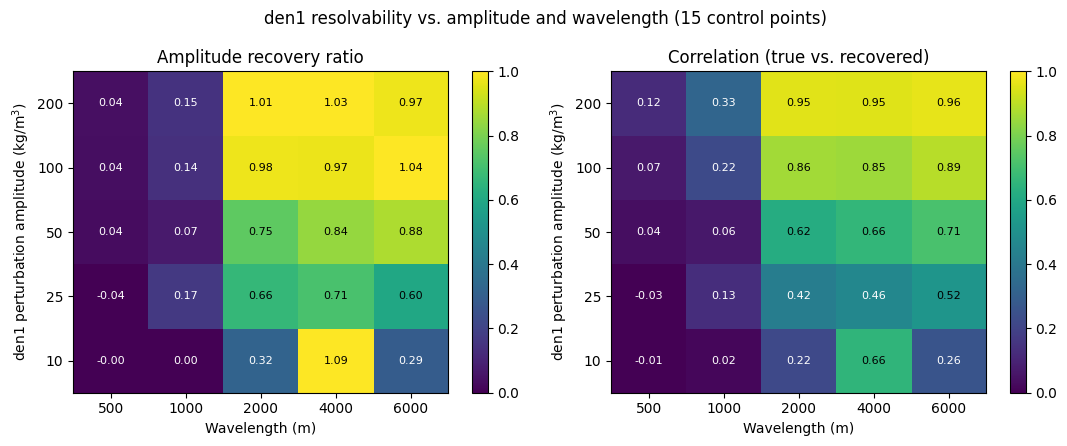

Saved amp_wavelength_map_den1.png

=== (B) Bulk/DC-shift recovery test, field=den1 ===
true_shift=   5 kg/m^3  recovered=   4.84 +/-  4.48 kg/m^3  (n=10)
true_shift=  10 kg/m^3  recovered=  11.10 +/-  4.01 kg/m^3  (n=10)
true_shift=  25 kg/m^3  recovered=  24.26 +/-  3.20 kg/m^3  (n=10)
true_shift=  50 kg/m^3  recovered=  49.09 +/-  2.05 kg/m^3  (n=10)
true_shift= 100 kg/m^3  recovered=  98.97 +/-  2.58 kg/m^3  (n=10)
true_shift= 200 kg/m^3  recovered= 201.31 +/-  4.71 kg/m^3  (n=10)
true_shift=   0 kg/m^3  recovered=   1.12 +/-  3.01 kg/m^3  (n=10)  <- noise floor


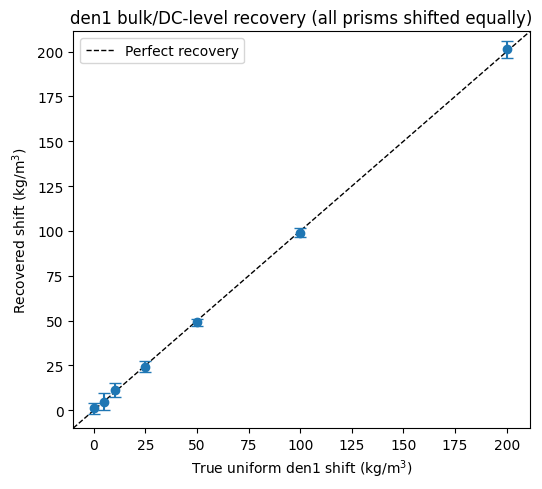

Saved bulk_shift_recovery_den1.png


In [ ]:
"""
Follow-up analysis #1 and #2 for the den1 checkerboard resolution test
==================================================================================
"""

import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt



PERTURB_FIELD = "den1"   # Set to den1


# ======================================================================
# (A) AMPLITUDE x WAVELENGTH RESOLUTION MAP
# ======================================================================

# Using kg/m^3 for density amplitudes
AMPLITUDES_DEN = [10, 25, 50, 100, 200]
WAVELENGTHS_M_A = [500, 1000, 2000, 4000,6000]
N_CTRL_A = 15
N_REPEATS_A = 4
PRIOR_STD_SCALE = 3.0


def invert_den1_perturbation(d_obs, ctrl_x, prior_std):
    """Same MAP machinery as the main script, factored out so both follow-up
    tests can call it with different amplitude-dependent PRIOR_STD."""
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        den1 = DEN1_BG + pert_field

        # No geometric boundary checks needed here because bd1 and bd2 are fixed
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG, TD, den1, DEN2_BG)

        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = ctrl_pert / prior_std
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * max(prior_std / PRIOR_STD_SCALE, 1.0)
    result = least_squares(residuals, x0, method="trf", bounds=(-bound, bound),
                            xtol=1e-10, ftol=1e-10)
    return controls_to_field(result.x, ctrl_x)


def run_amplitude_wavelength_map():
    rng = np.random.default_rng(RANDOM_SEED + 1)
    ctrl_x = make_control_grid(N_CTRL_A)

    amp_ratio_grid = np.zeros((len(AMPLITUDES_DEN), len(WAVELENGTHS_M_A)))
    corr_grid = np.zeros_like(amp_ratio_grid)

    for ia, amp in enumerate(AMPLITUDES_DEN):
        prior_std = PRIOR_STD_SCALE * amp
        for iw, wavelength in enumerate(WAVELENGTHS_M_A):
            true_pert = amp * np.sin(2.0 * np.pi * CO / wavelength)
            den1_true = DEN1_BG + true_pert
            clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG,
                                               TD, den1_true, DEN2_BG)

            amp_ratios, corrs = [], []
            for _ in range(N_REPEATS_A):
                noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise
                recovered_pert = invert_den1_perturbation(d_obs, ctrl_x, prior_std)
                ar, cr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(ar)
                corrs.append(cr)

            amp_ratio_grid[ia, iw] = np.mean(amp_ratios)
            corr_grid[ia, iw] = np.mean(corrs)
            print(f"amp={amp:4d} kg/m^3  wavelength={wavelength:5d} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}  corr={np.mean(corrs):5.2f}")

    return amp_ratio_grid, corr_grid


def plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid, save_path="amp_wavelength_map_den1.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, grid, title in [(axes[0], amp_ratio_grid, "Amplitude recovery ratio"),
                             (axes[1], corr_grid, "Correlation (true vs. recovered)")]:
        im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1,
                        extent=[0, len(WAVELENGTHS_M_A), 0, len(AMPLITUDES_DEN)])
        ax.set_xticks(np.arange(len(WAVELENGTHS_M_A)) + 0.5)
        ax.set_xticklabels(WAVELENGTHS_M_A)
        ax.set_yticks(np.arange(len(AMPLITUDES_DEN)) + 0.5)
        ax.set_yticklabels(AMPLITUDES_DEN)
        ax.set_xlabel("Wavelength (m)")
        ax.set_ylabel("den1 perturbation amplitude (kg/m$^3$)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
        for ia in range(len(AMPLITUDES_DEN)):
            for iw in range(len(WAVELENGTHS_M_A)):
                ax.text(iw + 0.5, ia + 0.5, f"{grid[ia, iw]:.2f}", ha="center", va="center",
                         color="white" if grid[ia, iw] < 0.5 else "black", fontsize=8)
    fig.suptitle(f"den1 resolvability vs. amplitude and wavelength ({N_CTRL_A} control points)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# (B) BULK / DC-SHIFT RECOVERABILITY TEST
# ======================================================================

# Shift magnitudes in kg/m^3
SHIFT_MAGNITUDES_DEN = [5, 10, 25, 50, 100, 200]
N_REPEATS_B = 10
SHIFT_PRIOR_STD = 1000.0


def invert_bulk_shift(d_obs):
    """Fit a single scalar uniform shift to den1"""
    def residuals(shift):
        den1 = DEN1_BG + shift[0]
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG, TD, den1, DEN2_BG)
        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = np.array([shift[0] / SHIFT_PRIOR_STD])
        return np.concatenate([data_resid, prior_resid])

    result = least_squares(residuals, x0=[0.0], method="trf",
                            bounds=(-3000, 3000), xtol=1e-12, ftol=1e-12)
    return result.x[0]


def run_bulk_shift_test():
    rng = np.random.default_rng(RANDOM_SEED + 2)
    records = []

    for true_shift in SHIFT_MAGNITUDES_DEN:
        den1_true = DEN1_BG + true_shift
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG,
                                           TD, den1_true, DEN2_BG)
        recovered = []
        for _ in range(N_REPEATS_B):
            noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
            d_obs = clean_data + noise
            recovered.append(invert_bulk_shift(d_obs))
        recovered = np.array(recovered)
        records.append((true_shift, recovered.mean(), recovered.std()))
        print(f"true_shift={true_shift:4d} kg/m^3  recovered={recovered.mean():7.2f} "
              f"+/- {recovered.std():5.2f} kg/m^3  (n={N_REPEATS_B})")

    # also run a true_shift=0 control
    den1_true = DEN1_BG.copy()
    clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG, TD, den1_true, DEN2_BG)
    recovered0 = []
    for _ in range(N_REPEATS_B):
        noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
        d_obs = clean_data + noise
        recovered0.append(invert_bulk_shift(d_obs))
    recovered0 = np.array(recovered0)
    print(f"true_shift=   0 kg/m^3  recovered={recovered0.mean():7.2f} "
          f"+/- {recovered0.std():5.2f} kg/m^3  (n={N_REPEATS_B})  <- noise floor")

    return records, (0.0, recovered0.mean(), recovered0.std())


def plot_bulk_shift_test(records, zero_record, save_path="bulk_shift_recovery_den1.png"):
    true_shifts = np.array([0.0] + [r[0] for r in records])
    recovered_means = np.array([zero_record[1]] + [r[1] for r in records])
    recovered_stds = np.array([zero_record[2]] + [r[2] for r in records])

    fig, ax = plt.subplots(figsize=(5.5, 5))
    lims = [min(true_shifts.min(), recovered_means.min()) - 10,
            max(true_shifts.max(), recovered_means.max()) + 10]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect recovery")
    ax.errorbar(true_shifts, recovered_means, yerr=recovered_stds, fmt="o", capsize=4,
                color="tab:blue")
    ax.set_xlabel("True uniform den1 shift (kg/m$^3$)")
    ax.set_ylabel("Recovered shift (kg/m$^3$)")
    ax.set_title("den1 bulk/DC-level recovery (all prisms shifted equally)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# RUN
# ======================================================================

if __name__ == "__main__":
    print("=== (A) Amplitude x wavelength map, field=den1 ===")
    amp_ratio_grid, corr_grid = run_amplitude_wavelength_map()
    plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid)

    print("\n=== (B) Bulk/DC-shift recovery test, field=den1 ===")
    records, zero_record = run_bulk_shift_test()
    plot_bulk_shift_test(records, zero_record)

field=den2   n_ctrl= 5  wavelength=  250 m  amp_ratio=-0.02+/-0.04  corr=-0.03+/-0.06  (n=6)
field=den2   n_ctrl=10  wavelength=  250 m  amp_ratio= 0.07+/-0.11  corr= 0.08+/-0.13  (n=6)
field=den2   n_ctrl=15  wavelength=  250 m  amp_ratio= 0.14+/-0.11  corr= 0.12+/-0.08  (n=6)
field=den2   n_ctrl=20  wavelength=  250 m  amp_ratio= 0.03+/-0.13  corr= 0.06+/-0.18  (n=6)
field=den2   n_ctrl= 5  wavelength=  350 m  amp_ratio= 0.07+/-0.05  corr= 0.07+/-0.06  (n=6)
field=den2   n_ctrl=10  wavelength=  350 m  amp_ratio= 0.06+/-0.11  corr= 0.07+/-0.12  (n=6)
field=den2   n_ctrl=15  wavelength=  350 m  amp_ratio=-0.02+/-0.08  corr=-0.04+/-0.08  (n=6)
field=den2   n_ctrl=20  wavelength=  350 m  amp_ratio= 0.08+/-0.09  corr= 0.10+/-0.10  (n=6)
field=den2   n_ctrl= 5  wavelength=  500 m  amp_ratio=-0.01+/-0.06  corr= 0.00+/-0.06  (n=6)
field=den2   n_ctrl=10  wavelength=  500 m  amp_ratio= 0.01+/-0.06  corr= 0.00+/-0.06  (n=6)
field=den2   n_ctrl=15  wavelength=  500 m  amp_ratio= 0.02+/-0.04  co

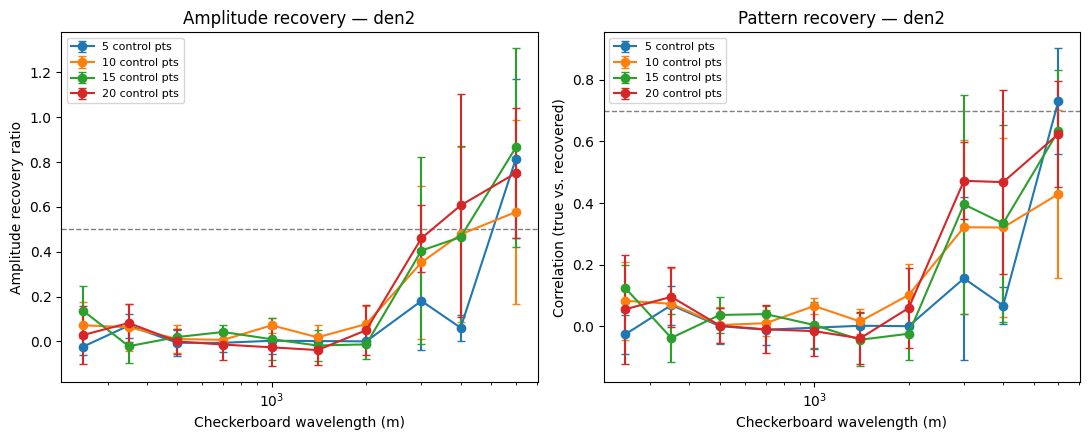

Saved resolution-curve figure to resolution_curves.png


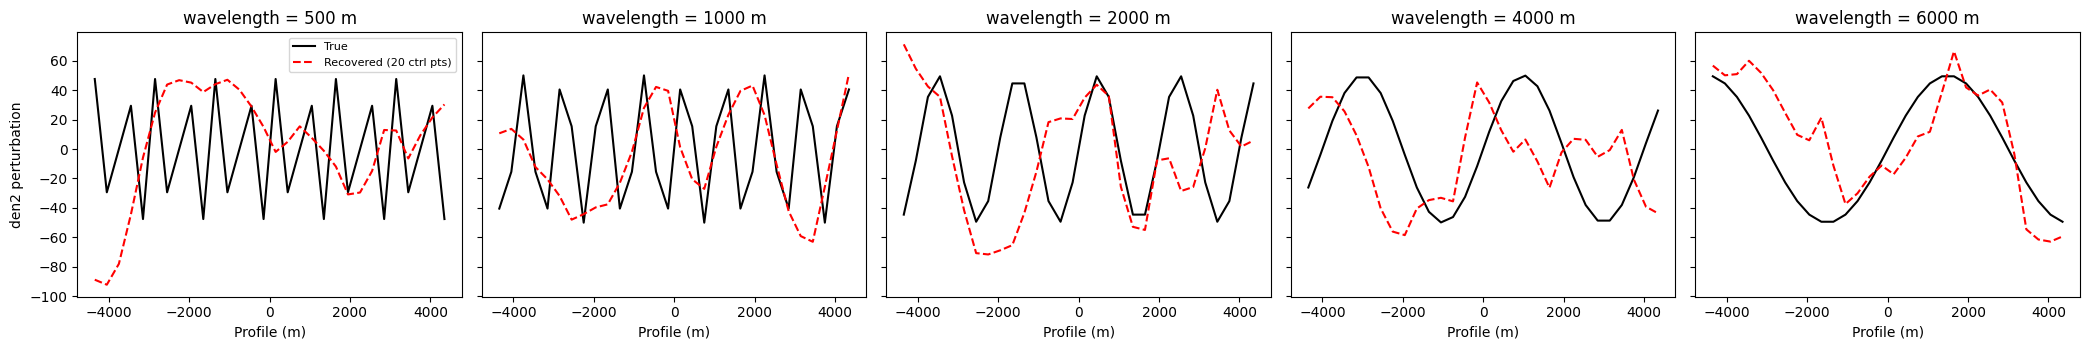

Saved example-recovery figure to example_recovery.png


In [ ]:

import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ======================================================================
# 1. YOUR FORWARD MODEL -- copied verbatim, not modified
# ======================================================================

def g_anomaly(x, A, m, D, d, rho):
    G = 6.67 * (10 ** -6)
    r1 = (((x - A) + (0.5 * m)) ** 2) + ((d) ** 2)
    r2 = (((x - A) + (0.5 * m)) ** 2) + ((D) ** 2)
    r3 = (((x - A) - (0.5 * m)) ** 2) + ((d) ** 2)
    r4 = (((x - A) - (0.5 * m)) ** 2) + ((D) ** 2)
    f1 = np.arctan((x - A + (0.5 * m)) / (D)) - np.arctan((x - A - (0.5 * m)) / (D))
    f2 = np.arctan((x - A + (0.5 * m)) / d) - np.arctan((x - A - (0.5 * m)) / d)
    f3 = 0.5 * (x - A) * (np.log10((r2 * r3) / (r1 * r4)))
    f4 = 0.25 * m * (np.log10((r2 * r4) / (r1 * r3)))
    f = ((D) * f1) - (d * f2) + f3 + f4
    g = 2 * G * rho * f  # in milligal
    return g


def g_n_anomaly(N, x, A, m, D, d, rho):
    u = 0
    for i in range(N):
        v = g_anomaly(x, A[i], m[i], D[i], d[i], rho[i])
        u = u + v
    return u


def measure_func_general(x, n, co, wid, bd1, bd2, td, den1, den2):
    """Your measure_func, generalized to take bd1/bd2/den1/den2 as arguments
    instead of closing over module-level globals, so the inversion can pass
    in trial models."""
    return (g_n_anomaly(n, x, co, wid, bd1, td, den1)
            + g_n_anomaly(n, x, co, wid, bd2, bd1, den2))


# ======================================================================
# 2. USER-EDITABLE SETTINGS
# ======================================================================

N_PRISM = 30
CO = np.linspace(-4350, 4350, N_PRISM)          # prism centers
WID = np.full(N_PRISM, 300.0)                   # prism widths
TD = np.full(N_PRISM, 1e-6)                     # top of layer 1 (~surface, fixed, never perturbed)
BD1_BG = np.array([500, 510, 520, 530, 540, 545, 550, 545, 540, 530, 520, 490, 470,
                    460, 450, 440, 420, 410, 400, 390, 385, 380, 385, 390, 400, 410,
                    420, 430, 460, 470], dtype=float)
BD2_BG = np.array([800, 790, 780, 770, 760, 755, 750, 755, 760, 770, 780, 810, 830,
                    840, 850, 860, 880, 890, 900, 910, 915, 920, 915, 910, 900, 890,
                    880, 870, 850, 830], dtype=float)
DEN1_BG = np.array([-100 - i * 3 for i in range(N_PRISM)], dtype=float)
DEN2_BG = np.array([-220 - i * 2 for i in range(N_PRISM)], dtype=float)

# --- observation stations (matches your X = np.linspace(-5000,5000,50)) ---
N_OBS = 50
X_OBS = np.linspace(-5000, 5000, N_OBS)

# --- which field to run the resolution test on ---
# one of: "bd1", "bd2", "den1", "den2"
PERTURB_FIELD = "den2"
PERTURB_AMPLITUDE = 50           # m for bd1/bd2, kg/m^3 for den1/den2

NOISE_STD_MGAL = 0.5
USE_COMPOUND_NOISE = False

# --- control-point densities and wavelengths to sweep ---
N_CTRL_LIST = [5, 10, 15, 20]
WAVELENGTHS_M = [250, 350, 500, 700, 1000, 1400, 2000, 3000, 4000,6000]

# --- noise realizations per (wavelength, n_ctrl) point ---
N_REPEATS = 6


PRIOR_STD = 3.0 * PERTURB_AMPLITUDE

# --- recovery thresholds that define "resolved" ---
AMP_RATIO_THRESHOLD = 0.5
CORR_THRESHOLD = 0.7

# --- optimizer / misc ---
RANDOM_SEED = 20260828


def make_compound_noise(rng, x_shape):
    """Reproduces your notebook's compound noise generator (Gaussian +
    random-walk + salt&pepper + systematic), for use if USE_COMPOUND_NOISE=True."""
    gaussian_noise = rng.normal(0, 0.3, size=x_shape)
    random_steps = rng.normal(0, 0.1, size=x_shape)
    random_walk_noise = np.cumsum(random_steps)
    salt_prob, pepper_prob, noise_level = 0.05, 0.05, 0.05
    salt_and_pepper_noise = rng.choice(
        [0, 1, -1], size=x_shape, p=[1 - (salt_prob + pepper_prob), salt_prob, pepper_prob]
    ) * noise_level
    a, b, c = 0.001, 0.0001, 0.001
    systematic_noise_level = 0.05
    systematic_noise = systematic_noise_level * (
        (a * ((X_OBS * 0.01) ** 2)) + (b * ((X_OBS * 0.01) ** 3)) + c
    )
    return gaussian_noise + random_walk_noise + salt_and_pepper_noise + systematic_noise


# ======================================================================
# 3. REDUCED-BASIS (PIECEWISE-LINEAR CONTROL-POINT) PARAMETERIZATION
# ======================================================================

def make_control_grid(n_ctrl):
    return np.linspace(CO.min(), CO.max(), n_ctrl)


def controls_to_field(ctrl_values, ctrl_x, prism_x=CO):
    """Piecewise-linear interpolation from control points to full prism
    resolution -- matches the reduced-basis parameterization in 3.3.5."""
    return np.interp(prism_x, ctrl_x, ctrl_values)


# ======================================================================
# 4. CHECKERBOARD (SINUSOIDAL) SYNTHETIC MODEL
# ======================================================================

def build_true_field(field_name, wavelength, amplitude):
    bd1 = BD1_BG.copy()
    bd2 = BD2_BG.copy()
    den1 = DEN1_BG.copy()
    den2 = DEN2_BG.copy()

    perturbation = amplitude * np.sin(2.0 * np.pi * CO / wavelength)
    if field_name == "bd1":
        bd1 = bd1 + perturbation
    elif field_name == "bd2":
        bd2 = bd2 + perturbation
    elif field_name == "den1":
        den1 = den1 + perturbation
    elif field_name == "den2":
        den2 = den2 + perturbation
    else:
        raise ValueError(f"Unknown PERTURB_FIELD: {field_name}")

    if np.any(bd1 >= bd2):
        raise ValueError("Perturbation makes bd1 >= bd2 somewhere -- reduce "
                          "PERTURB_AMPLITUDE or check the field being perturbed.")

    return bd1, bd2, den1, den2, perturbation


# ======================================================================
# 5. MAP INVERSION (control points -> best fit to synthetic data)
# ======================================================================

def invert_control_points(d_obs, noise_std, ctrl_x, field_name):
    """
    Fit control-point values for `field_name` (others fixed at background) by
    minimizing [data misfit] + [weak Gaussian prior], via
    scipy.optimize.least_squares with a finite-difference Jacobian (your
    forward model isn't auto-differentiable).
    """
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)  # optimize the PERTURBATION around background

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        bd1, bd2, den1, den2 = BD1_BG.copy(), BD2_BG.copy(), DEN1_BG.copy(), DEN2_BG.copy()
        if field_name == "bd1":
            bd1 = bd1 + pert_field
        elif field_name == "bd2":
            bd2 = bd2 + pert_field
        elif field_name == "den1":
            den1 = den1 + pert_field
        elif field_name == "den2":
            den2 = den2 + pert_field

        # keep the forward model well-defined even if the optimizer proposes
        # a physically invalid crossing mid-search; penalize instead of crashing
        if np.any(bd1 <= 0) or np.any(bd2 <= bd1):
            return np.full(len(X_OBS) + n_ctrl, 1e3)

        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)
        data_resid = (pred - d_obs) / noise_std
        prior_resid = ctrl_pert / PRIOR_STD
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * PERTURB_AMPLITUDE
    result = least_squares(residuals, x0, method="trf",
                            bounds=(-bound, bound), xtol=1e-10, ftol=1e-10)

    recovered_pert = controls_to_field(result.x, ctrl_x)
    return recovered_pert


# ======================================================================
# 6. RECOVERY METRICS
# ======================================================================

def recovery_metrics(true_pert, recovered_pert):
    """
    amp_ratio: best-fit scalar (least-squares projection of recovered onto
               true) -- 1.0 = full amplitude recovered, 0.0 = smoothed away.
    corr:      Pearson correlation -- checks the pattern/phase was recovered.
    """
    denom = np.sum(true_pert ** 2)
    amp_ratio = float(np.sum(recovered_pert * true_pert) / denom) if denom > 0 else np.nan
    if np.std(true_pert) > 0 and np.std(recovered_pert) > 0:
        corr = float(np.corrcoef(true_pert, recovered_pert)[0, 1])
    else:
        corr = np.nan
    return amp_ratio, corr


# ======================================================================
# 7. MAIN SWEEP
# ======================================================================

def run_resolution_sweep():
    rng = np.random.default_rng(RANDOM_SEED)

    results = {n_ctrl: {"wavelength": [], "amp_ratio_mean": [], "amp_ratio_std": [],
                         "corr_mean": [], "corr_std": []} for n_ctrl in N_CTRL_LIST}
    example_cache = {}

    for wavelength in WAVELENGTHS_M:
        bd1, bd2, den1, den2, true_pert = build_true_field(PERTURB_FIELD, wavelength, PERTURB_AMPLITUDE)
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, bd1, bd2, TD, den1, den2)

        for n_ctrl in N_CTRL_LIST:
            ctrl_x = make_control_grid(n_ctrl)
            amp_ratios, corrs = [], []

            for rep in range(N_REPEATS):
                if USE_COMPOUND_NOISE:
                    noise = make_compound_noise(rng, X_OBS.shape)
                else:
                    noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise

                recovered_pert = invert_control_points(d_obs, NOISE_STD_MGAL, ctrl_x, PERTURB_FIELD)
                amp_ratio, corr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(amp_ratio)
                corrs.append(corr)

                if rep == 0 and n_ctrl == 20 and wavelength in (500, 1000, 2000, 4000,6000):
                    example_cache[wavelength] = (true_pert.copy(), recovered_pert.copy())

            results[n_ctrl]["wavelength"].append(wavelength)
            results[n_ctrl]["amp_ratio_mean"].append(float(np.mean(amp_ratios)))
            results[n_ctrl]["amp_ratio_std"].append(float(np.std(amp_ratios)))
            results[n_ctrl]["corr_mean"].append(float(np.mean(corrs)))
            results[n_ctrl]["corr_std"].append(float(np.std(corrs)))

            print(f"field={PERTURB_FIELD:5s}  n_ctrl={n_ctrl:2d}  wavelength={wavelength:5.0f} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}+/-{np.std(amp_ratios):.2f}  "
                  f"corr={np.mean(corrs):5.2f}+/-{np.std(corrs):.2f}  (n={N_REPEATS})")

    return results, example_cache


def shortest_recoverable_wavelength(results):
    summary = {}
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        amp = np.array(r["amp_ratio_mean"])
        corr = np.array(r["corr_mean"])
        order = np.argsort(wl)
        wl, amp, corr = wl[order], amp[order], corr[order]
        ok = (amp >= AMP_RATIO_THRESHOLD) & (corr >= CORR_THRESHOLD)
        summary[n_ctrl] = float(wl[ok][0]) if ok.any() else float("nan")
    return summary


# ======================================================================
# 8. PLOTTING
# ======================================================================

def plot_resolution_curves(results, save_path="resolution_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for n_ctrl, r in results.items():
        wl = np.array(r["wavelength"])
        order = np.argsort(wl)
        axes[0].errorbar(wl[order], np.array(r["amp_ratio_mean"])[order],
                          yerr=np.array(r["amp_ratio_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")
        axes[1].errorbar(wl[order], np.array(r["corr_mean"])[order],
                          yerr=np.array(r["corr_std"])[order],
                          marker="o", capsize=3, label=f"{n_ctrl} control pts")

    axes[0].axhline(AMP_RATIO_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Checkerboard wavelength (m)")
    axes[0].set_ylabel("Amplitude recovery ratio")
    axes[0].set_title(f"Amplitude recovery — {PERTURB_FIELD}")
    axes[0].set_xscale("log")
    axes[0].legend(fontsize=8)

    axes[1].axhline(CORR_THRESHOLD, color="gray", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Checkerboard wavelength (m)")
    axes[1].set_ylabel("Correlation (true vs. recovered)")
    axes[1].set_title(f"Pattern recovery — {PERTURB_FIELD}")
    axes[1].set_xscale("log")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved resolution-curve figure to {save_path}")


def plot_example_recovery(example_cache, save_path="example_recovery.png"):
    n = len(example_cache)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, (wavelength, (true_pert, recovered_pert)) in zip(axes, sorted(example_cache.items())):
        ax.plot(CO, true_pert, "k-", label="True")
        ax.plot(CO, recovered_pert, "r--", label="Recovered (20 ctrl pts)")
        ax.set_title(f"wavelength = {wavelength} m")
        ax.set_xlabel("Profile (m)")
    axes[0].set_ylabel(f"{PERTURB_FIELD} perturbation")
    axes[0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved example-recovery figure to {save_path}")


# ======================================================================
# 9. RUN
# ======================================================================

if __name__ == "__main__":
    results, example_cache = run_resolution_sweep()
    summary = shortest_recoverable_wavelength(results)

    print("\nShortest recoverable wavelength per control-point density "
          f"(amp_ratio >= {AMP_RATIO_THRESHOLD}, corr >= {CORR_THRESHOLD}):")
    for n_ctrl in N_CTRL_LIST:
        wl = summary[n_ctrl]
        print(f"  {n_ctrl:2d} control points -> {wl:.0f} m" if not np.isnan(wl)
              else f"  {n_ctrl:2d} control points -> not resolved in tested range")

    plot_resolution_curves(results)
    plot_example_recovery(example_cache)

=== (A) Amplitude x wavelength map, field=den2 ===
amp=  10 kg/m^3  wavelength=  500 m  amp_ratio= 0.00  corr= 0.01
amp=  10 kg/m^3  wavelength= 1000 m  amp_ratio=-0.01  corr=-0.03
amp=  10 kg/m^3  wavelength= 2000 m  amp_ratio=-0.00  corr=-0.02
amp=  10 kg/m^3  wavelength= 4000 m  amp_ratio= 0.30  corr= 0.37
amp=  10 kg/m^3  wavelength= 6000 m  amp_ratio=-0.02  corr= 0.10
amp=  25 kg/m^3  wavelength=  500 m  amp_ratio=-0.04  corr=-0.05
amp=  25 kg/m^3  wavelength= 1000 m  amp_ratio=-0.00  corr=-0.01
amp=  25 kg/m^3  wavelength= 2000 m  amp_ratio= 0.00  corr=-0.00
amp=  25 kg/m^3  wavelength= 4000 m  amp_ratio= 0.09  corr= 0.12
amp=  25 kg/m^3  wavelength= 6000 m  amp_ratio= 0.03  corr= 0.14
amp=  50 kg/m^3  wavelength=  500 m  amp_ratio= 0.04  corr= 0.03
amp=  50 kg/m^3  wavelength= 1000 m  amp_ratio= 0.03  corr= 0.03
amp=  50 kg/m^3  wavelength= 2000 m  amp_ratio= 0.09  corr= 0.10
amp=  50 kg/m^3  wavelength= 4000 m  amp_ratio= 0.37  corr= 0.36
amp=  50 kg/m^3  wavelength= 6000 m  am

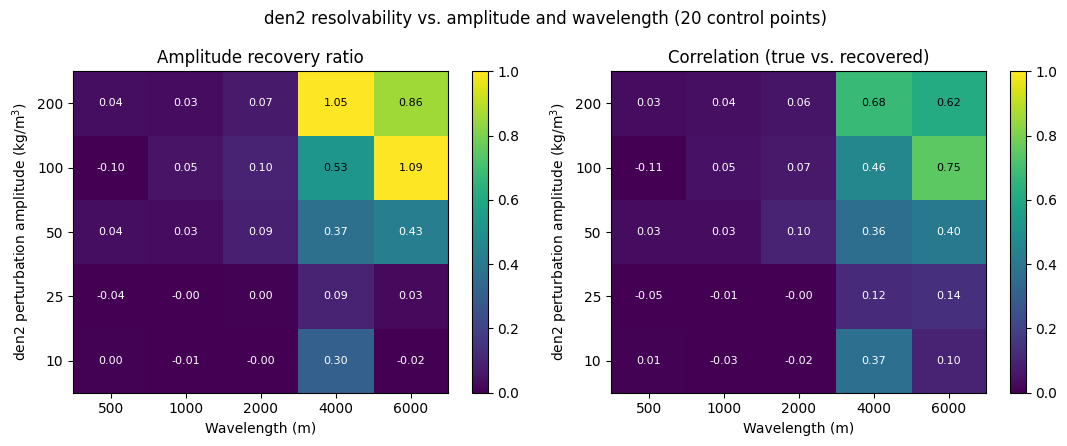

Saved amp_wavelength_map_den2.png

=== (B) Bulk/DC-shift recovery test, field=den2 ===
true_shift=   5 kg/m^3  recovered=   4.09 +/-  5.93 kg/m^3  (n=10)
true_shift=  10 kg/m^3  recovered=  11.69 +/-  5.36 kg/m^3  (n=10)
true_shift=  25 kg/m^3  recovered=  25.43 +/-  4.50 kg/m^3  (n=10)
true_shift=  50 kg/m^3  recovered=  47.61 +/-  3.13 kg/m^3  (n=10)
true_shift= 100 kg/m^3  recovered=  98.66 +/-  3.71 kg/m^3  (n=10)
true_shift= 200 kg/m^3  recovered= 202.21 +/-  6.64 kg/m^3  (n=10)
true_shift=   0 kg/m^3  recovered=   1.20 +/-  4.81 kg/m^3  (n=10)  <- noise floor


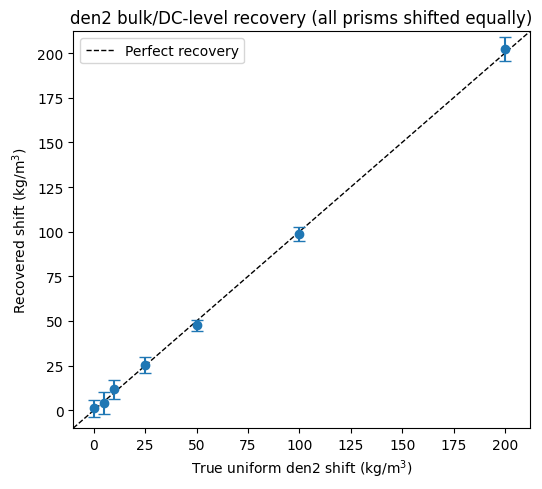

Saved bulk_shift_recovery_den2.png


In [ ]:
"""
Follow-up analysis #1 and #2 for the den2 checkerboard resolution test
==================================================================================
"""

import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt


PERTURB_FIELD = "den2"   # Set to den2


# ======================================================================
# (A) AMPLITUDE x WAVELENGTH RESOLUTION MAP
# ======================================================================

# Using kg/m^3 for density amplitudes
AMPLITUDES_DEN = [10, 25, 50, 100, 200]
WAVELENGTHS_M_A = [500, 1000, 2000, 4000,6000]
N_CTRL_A = 20
N_REPEATS_A = 4
PRIOR_STD_SCALE = 3.0


def invert_den2_perturbation(d_obs, ctrl_x, prior_std):
    """Same MAP machinery as the main script, factored out so both follow-up
    tests can call it with different amplitude-dependent PRIOR_STD."""
    n_ctrl = ctrl_x.shape[0]
    x0 = np.zeros(n_ctrl)

    def residuals(ctrl_pert):
        pert_field = controls_to_field(ctrl_pert, ctrl_x)
        den2 = DEN2_BG + pert_field

        # No geometric boundary checks needed here because bd1 and bd2 are fixed
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG, TD, DEN1_BG, den2)

        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = ctrl_pert / prior_std
        return np.concatenate([data_resid, prior_resid])

    bound = 4.0 * max(prior_std / PRIOR_STD_SCALE, 1.0)
    result = least_squares(residuals, x0, method="trf", bounds=(-bound, bound),
                           xtol=1e-10, ftol=1e-10)
    return controls_to_field(result.x, ctrl_x)


def run_amplitude_wavelength_map():
    rng = np.random.default_rng(RANDOM_SEED + 1)
    ctrl_x = make_control_grid(N_CTRL_A)

    amp_ratio_grid = np.zeros((len(AMPLITUDES_DEN), len(WAVELENGTHS_M_A)))
    corr_grid = np.zeros_like(amp_ratio_grid)

    for ia, amp in enumerate(AMPLITUDES_DEN):
        prior_std = PRIOR_STD_SCALE * amp
        for iw, wavelength in enumerate(WAVELENGTHS_M_A):
            true_pert = amp * np.sin(2.0 * np.pi * CO / wavelength)
            den2_true = DEN2_BG + true_pert
            clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG,
                                              TD, DEN1_BG, den2_true)

            amp_ratios, corrs = [], []
            for _ in range(N_REPEATS_A):
                noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
                d_obs = clean_data + noise
                recovered_pert = invert_den2_perturbation(d_obs, ctrl_x, prior_std)
                ar, cr = recovery_metrics(true_pert, recovered_pert)
                amp_ratios.append(ar)
                corrs.append(cr)

            amp_ratio_grid[ia, iw] = np.mean(amp_ratios)
            corr_grid[ia, iw] = np.mean(corrs)
            print(f"amp={amp:4d} kg/m^3  wavelength={wavelength:5d} m  "
                  f"amp_ratio={np.mean(amp_ratios):5.2f}  corr={np.mean(corrs):5.2f}")

    return amp_ratio_grid, corr_grid


def plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid, save_path="amp_wavelength_map_den2.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, grid, title in [(axes[0], amp_ratio_grid, "Amplitude recovery ratio"),
                             (axes[1], corr_grid, "Correlation (true vs. recovered)")]:
        im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1,
                        extent=[0, len(WAVELENGTHS_M_A), 0, len(AMPLITUDES_DEN)])
        ax.set_xticks(np.arange(len(WAVELENGTHS_M_A)) + 0.5)
        ax.set_xticklabels(WAVELENGTHS_M_A)
        ax.set_yticks(np.arange(len(AMPLITUDES_DEN)) + 0.5)
        ax.set_yticklabels(AMPLITUDES_DEN)
        ax.set_xlabel("Wavelength (m)")
        ax.set_ylabel("den2 perturbation amplitude (kg/m$^3$)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
        for ia in range(len(AMPLITUDES_DEN)):
            for iw in range(len(WAVELENGTHS_M_A)):
                ax.text(iw + 0.5, ia + 0.5, f"{grid[ia, iw]:.2f}", ha="center", va="center",
                         color="white" if grid[ia, iw] < 0.5 else "black", fontsize=8)
    fig.suptitle(f"den2 resolvability vs. amplitude and wavelength ({N_CTRL_A} control points)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# (B) BULK / DC-SHIFT RECOVERABILITY TEST
# ======================================================================

# Shift magnitudes in kg/m^3
SHIFT_MAGNITUDES_DEN = [5, 10, 25, 50, 100, 200]
N_REPEATS_B = 10
SHIFT_PRIOR_STD = 1000.0


def invert_bulk_shift(d_obs):
    """Fit a single scalar uniform shift to den2"""
    def residuals(shift):
        den2 = DEN2_BG + shift[0]
        pred = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG, TD, DEN1_BG, den2)
        data_resid = (pred - d_obs) / NOISE_STD_MGAL
        prior_resid = np.array([shift[0] / SHIFT_PRIOR_STD])
        return np.concatenate([data_resid, prior_resid])

    result = least_squares(residuals, x0=[0.0], method="trf",
                           bounds=(-3000, 3000), xtol=1e-12, ftol=1e-12)
    return result.x[0]


def run_bulk_shift_test():
    rng = np.random.default_rng(RANDOM_SEED + 2)
    records = []

    for true_shift in SHIFT_MAGNITUDES_DEN:
        den2_true = DEN2_BG + true_shift
        clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG,
                                           TD, DEN1_BG, den2_true)
        recovered = []
        for _ in range(N_REPEATS_B):
            noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
            d_obs = clean_data + noise
            recovered.append(invert_bulk_shift(d_obs))
        recovered = np.array(recovered)
        records.append((true_shift, recovered.mean(), recovered.std()))
        print(f"true_shift={true_shift:4d} kg/m^3  recovered={recovered.mean():7.2f} "
              f"+/- {recovered.std():5.2f} kg/m^3  (n={N_REPEATS_B})")

    # also run a true_shift=0 control
    den2_true = DEN2_BG.copy()
    clean_data = measure_func_general(X_OBS, N_PRISM, CO, WID, BD1_BG, BD2_BG, TD, DEN1_BG, den2_true)
    recovered0 = []
    for _ in range(N_REPEATS_B):
        noise = rng.normal(0.0, NOISE_STD_MGAL, size=X_OBS.shape[0])
        d_obs = clean_data + noise
        recovered0.append(invert_bulk_shift(d_obs))
    recovered0 = np.array(recovered0)
    print(f"true_shift=   0 kg/m^3  recovered={recovered0.mean():7.2f} "
          f"+/- {recovered0.std():5.2f} kg/m^3  (n={N_REPEATS_B})  <- noise floor")

    return records, (0.0, recovered0.mean(), recovered0.std())


def plot_bulk_shift_test(records, zero_record, save_path="bulk_shift_recovery_den2.png"):
    true_shifts = np.array([0.0] + [r[0] for r in records])
    recovered_means = np.array([zero_record[1]] + [r[1] for r in records])
    recovered_stds = np.array([zero_record[2]] + [r[2] for r in records])

    fig, ax = plt.subplots(figsize=(5.5, 5))
    lims = [min(true_shifts.min(), recovered_means.min()) - 10,
            max(true_shifts.max(), recovered_means.max()) + 10]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect recovery")
    ax.errorbar(true_shifts, recovered_means, yerr=recovered_stds, fmt="o", capsize=4,
                color="tab:blue")
    ax.set_xlabel("True uniform den2 shift (kg/m$^3$)")
    ax.set_ylabel("Recovered shift (kg/m$^3$)")
    ax.set_title("den2 bulk/DC-level recovery (all prisms shifted equally)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved {save_path}")


# ======================================================================
# RUN
# ======================================================================

if __name__ == "__main__":
    print("=== (A) Amplitude x wavelength map, field=den2 ===")
    amp_ratio_grid, corr_grid = run_amplitude_wavelength_map()
    plot_amplitude_wavelength_map(amp_ratio_grid, corr_grid)

    print("\n=== (B) Bulk/DC-shift recovery test, field=den2 ===")
    records, zero_record = run_bulk_shift_test()
    plot_bulk_shift_test(records, zero_record)

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict


#print(X.shape, y.shape)  # confirm: (50, 1) (50,)



In [ ]:
#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
#Defining bottom depths of two layers by bd1 and bd2. Each element of bd1 representing bottom depth value of one prism. same for bd2 in meter
bd1=np.array([500,510,520,530,540,545,550,545,540,530,520,490,470,460,450,440,420,410,400,390,385,380,385,390,400,410,420,430,460,470])
bd2=np.array([800,790,780,770,760,755,750,755,760,770,780,810,830,840,850,860,880,890,900,910,915,920,915,910,900,890,880,870,850,830])
n= 30 #We are considering 30 prisms here
#surface value in meter
td=np.zeros(n)
for j in range(n):
    td[j]= 10**-6 # in meter (taking MSL as our observing surface i.e no undulation)
# Defining centre value of horizontal co-ordinate of each prism
#co=np.arange(-4500,4500,300)
co=np.linspace(-4350,4350,n)
# Defining width of each prism
wid=np.zeros(n)
for j in range(n):
    wid[j]= 300 # in meter

#USING LINEAR VARIATION OF DENSITY
den1_L=np.zeros(n)
for i in range(30):
    den1_L[i]=-100-i*3
den2_L=np.zeros(n)
for i in range(n):
    den2_L[i]=-220-i*2
#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co[0]-(wid[0]*0.5)
xs[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs[i]=co[i-1]+(0.5*wid[i-1])
#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
zs1[0]=bd1[0]
zs1[n]=bd1[n-1]
for i in range(1,n):
    zs1[i]=bd1[i]
#Creating z2 co-ordinate values for 2nd layer for each prism
zs2=np.zeros(n+1)
zs2[0]=bd2[0]-5
zs2[n]=bd2[n-1]+5
for i in range(1,n):
    zs2[i]=(bd2[i-1]+bd2[i])*0.5
#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]
#Creating points for 1st layer
R1=np.zeros(((n+1),2))
for i in range(n+1):
    R1[i]=[xs[i],zs1[i]]

#Creating points for 1st layer
R1_1=np.zeros(((n+1),2))
for i in range(n):
    R1_1[i]=[xs[i+1],zs1[i]]
#Creating points for 2nd layer
R2=np.zeros(((n+1),2))
for i in range(n+1):
    R2[i]=[xs[i],zs2[i]]
#Creating points for 1st layer
R2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_1[i]=[xs[i+1],zs2[i]]

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=np.arctan((x-A+(0.5*m))/(D))-np.arctan((x-A-(0.5*m))/(D))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D)*f1)-(d*f2)+f3+f4
    g=2*G*rho*f #in miligal
    return g
#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
def g_n_anomaly(N,x,A,m,D,d,rho):
    u=0
    for i in range(N):
        v=g_anomaly(x,A[i],m[i],D[i],d[i],rho[i])
        u=u+v

    return u
#Defining "measure_func" function to calculate gravity anomaly for combined two layers in miligal with user defined station coordinates and above defined model parameters with some added random noise
def measure_func(x):
    return g_n_anomaly(n,x,co,wid,bd1,td,den1_L)+ g_n_anomaly(n,x,co,wid,bd2,bd1,den2_L)
NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS)#Measurement points along the profile -5000 meter to 5000 meter
X_test = np.linspace(-5000, 5000, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #gravity anomaly with no noise added

#import tensorflow as tf
# Set seeds for reproducibility
SEED = 45
np.random.seed(SEED)
#tf.random.set_seed(SEED)
#Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 0.3, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.1, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.05 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.05 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.01)**2))+(b*((X*0.01)**3))+c)

#Adding noise to the gravity anomaly data

y = measure_func(X) + random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)
y_f=interp1d(X,y,'linear')
y_true=y_f(X_test)#interpolating between noisy observations at finer fintervals

In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan((x-A+(0.5*m))/D)-jnp.arctan((x-A-(0.5*m))/D)
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=(D*f1)-(d*f2)+f3+f4
    return 2*G*rho*f


In [ ]:
X_flat = X[:, 0] if X.ndim > 1 else X
x_mean, x_std = X_flat.mean(), X_flat.std()

def normalize_x(Xin):
    Xin = jnp.asarray(Xin)
    if Xin.ndim == 1:
        return (Xin - x_mean) / x_std
    else:
        return Xin.at[:, 0].set((Xin[:, 0] - x_mean) / x_std)

# pass normalize_x(X) into custom_Matern_kernel(...) everywhere it's called
# (gp_model_reduced, gp_predict_reduced — both K_tt/K_st/K_ss calls)
def custom_Matern_kernel(X1: jnp.ndarray, X2: jnp.ndarray,
                          params: Dict[str, jnp.ndarray],
                          noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    lengthscale = params["k_length"]
    variance    = params["k_scale"] ** 2
    jitter      = kwargs.get("jitter", 1e-6)

    # Scale ONCE
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale

    # Pairwise squared distances
    D = (jnp.sum(X1_scaled**2, axis=1)[:, None] +
         jnp.sum(X2_scaled**2, axis=1) -
         2 * jnp.dot(X1_scaled, X2_scaled.T))
    D = jnp.sqrt(jnp.maximum(D, 1e-12))

    # Matern 3/2 formula
    sqrt3 = jnp.sqrt(3.0)
    K_mat = variance * (1 + sqrt3 * D) * jnp.exp(-sqrt3 * D)

    if X1.shape == X2.shape:
        K_mat += (noise + jitter) * jnp.eye(X1.shape[0])

    return K_mat


def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    k_scale  = numpyro.sample("k_scale",  dist.HalfNormal(1))
    k_length = numpyro.sample("k_length", dist.LogNormal(0, 1))
    return {"k_length": k_length, "k_scale": k_scale}


In [ ]:

import random
random.seed(42)
depth1_lo_bounds = [random.uniform(float(bd1[i])-200,float(bd1[i])-50) for i in range(n)]
depth1_hi_bounds = [random.uniform(float(bd1[i])+50,float(bd1[i])+200) for i in range(n)]

depth2_lo_bounds = [random.uniform(float(bd2[i])-200,float(bd2[i])-50) for i in range(n)]
depth2_hi_bounds = [random.uniform(float(bd2[i])+50,float(bd2[i])+200) for i in range(n)]

density1_lo_bounds = [random.uniform(float(den1_L[i])-20,float(den1_L[i])-10) for i in range(n)]
density1_hi_bounds = [random.uniform(float(den1_L[i])+10,float(den1_L[i])+20) for i in range(n)]

density2_lo_bounds = [random.uniform(float(den2_L[i])-20,float(den2_L[i])-10) for i in range(n)]
density2_hi_bounds = [random.uniform(float(den2_L[i])+10,float(den2_L[i])+20) for i in range(n)]

In [ ]:
## INCREASING MODEL RESOLUTION
n1 = 60
co1 = np.linspace(-4375, 4375, n1)

wid1 = np.zeros(n1)
for j in range(n1):
    wid1[j] = 9000 / n1  # in meters
td1 = np.zeros(n1)
from scipy import interpolate
y_f1=interpolate.interp1d(co, bd1, fill_value="extrapolate", kind='linear')
bd1_0=y_f1(co1)
y_f2=interpolate.interp1d(co, bd2, fill_value="extrapolate", kind='linear')
bd2_0=y_f2(co1)
y_f3=interpolate.interp1d(co, den1_L, fill_value="extrapolate", kind='linear')
den1_L0=y_f3(co1)
y_f4=interpolate.interp1d(co, den2_L, fill_value="extrapolate", kind='linear')
den2_L0=y_f4(co1)

thickness = bd2_0-bd1_0


import random
depth1_lo_bounds_80 = [random.uniform(float(bd1_0[i])-50,float(bd1_0[i])-20) for i in range(n1)]
depth1_hi_bounds_80 = [random.uniform(float(bd1_0[i])+20,float(bd1_0[i])+50) for i in range(n1)]

depth2_lo_bounds_80 = [random.uniform(float(bd2_0[i])-100,float(bd2_0[i])-50) for i in range(n1)]
depth2_hi_bounds_80 = [random.uniform(float(bd2_0[i])+50,float(bd2_0[i])+100) for i in range(n1)]

thickness_lo=[random.uniform(float(thickness[i])-50,float(thickness[i])-20) for i in range(n1)]
thickness_hi=[random.uniform(float(thickness[i])+20,float(thickness[i])+50) for i in range(n1)]


density1_lo_bounds_80 = [random.uniform(float(den1_L0[i])-20,float(den1_L0[i])-10) for i in range(n1)]
density1_hi_bounds_80 = [random.uniform(float(den1_L0[i])+10,float(den1_L0[i])+20) for i in range(n1)]

density2_lo_bounds_80 = [random.uniform(float(den2_L0[i])-20,float(den2_L0[i])-10) for i in range(n1)]
density2_hi_bounds_80 = [random.uniform(float(den2_L0[i])+10,float(den2_L0[i])+20) for i in range(n1)]

In [ ]:
# ═══════════════════════════════════════════════════════
# STEP 1: BASIS MATRICES — resolution-informed K per field
# ═══════════════════════════════════════════════════════
# From the checkerboard resolution tests: bd1/bd2 gain nothing from more
# control points (data-limited, not parameterization-limited); den1 clearly
# benefits from more points; den2 behaves like the depth fields, not like
# den1, because it's the deeper layer and its signal is more attenuated.
K_BD1  = 10
K_BD2  = 15
K_DEN1 = 20
K_DEN2 = 10
K_thickness = 15

x_anchors_bd1  = np.linspace(co1[0], co1[-1], K_BD1)
x_anchors_bd2  = np.linspace(co1[0], co1[-1], K_BD2)
x_anchors_den1 = np.linspace(co1[0], co1[-1], K_DEN1)
x_anchors_den2 = np.linspace(co1[0], co1[-1], K_DEN2)
x_anchors_thickness = np.linspace(co1[0], co1[-1], K_thickness)

def build_basis_matrix(x_full, x_anchors, K):
    """Piecewise-linear reduced-basis matrix, shape (len(x_full), K)."""
    B = np.zeros((len(x_full), K))
    for k in range(K):
        anchor_vals = np.zeros(K)
        anchor_vals[k] = 1.0
        B[:, k] = np.interp(x_full, x_anchors, anchor_vals)
    return B

B_bd1  = jnp.array(build_basis_matrix(co1, x_anchors_bd1,  K_BD1))
B_bd2  = jnp.array(build_basis_matrix(co1, x_anchors_bd2,  K_BD2))
B_den1 = jnp.array(build_basis_matrix(co1, x_anchors_den1, K_DEN1))
B_den2 = jnp.array(build_basis_matrix(co1, x_anchors_den2, K_DEN2))
B_thickness = jnp.array(build_basis_matrix(co1, x_anchors_thickness, K_thickness))

print("B_bd1 :", B_bd1.shape,  "(expect", (n, K_BD1), ")")
print("B_bd2 :", B_bd2.shape,  "(expect", (n, K_BD2), ")")
print("B_den1:", B_den1.shape, "(expect", (n, K_DEN1), ")")
print("B_den2:", B_den2.shape, "(expect", (n, K_DEN2), ")")

# Project your existing per-prism bounds onto each field's own anchor grid
d1_lo_a   = np.interp(x_anchors_bd1,  co1, np.array(depth1_lo_bounds_80))
d1_hi_a   = np.interp(x_anchors_bd1,  co1, np.array(depth1_hi_bounds_80))
d2_lo_a   = np.interp(x_anchors_bd2,  co1, np.array(depth2_lo_bounds_80))
d2_hi_a   = np.interp(x_anchors_bd2,  co1, np.array(depth2_hi_bounds_80))
rho1_lo_a = np.interp(x_anchors_den1, co1, np.array(density1_lo_bounds_80))
rho1_hi_a = np.interp(x_anchors_den1, co1, np.array(density1_hi_bounds_80))
rho2_lo_a = np.interp(x_anchors_den2, co1, np.array(density2_lo_bounds_80))
rho2_hi_a = np.interp(x_anchors_den2, co1, np.array(density2_hi_bounds_80))
thickness_lo_a = np.interp(x_anchors_thickness, co1, np.array(thickness_lo))
thickness_hi_a = np.interp(x_anchors_thickness, co1, np.array(thickness_hi))


# ═══════════════════════════════════════════════════════
# STEP 2: REDUCED PRIOR + MEAN FUNCTION
# ═══════════════════════════════════════════════════════
def Bayes_Inf_prior_reduced():
    params = {}
    for k in range(K_BD1):
        params[f"B_D1_anchor_{k}"] = numpyro.sample(
            f"B_D1_anchor_{k}", dist.Uniform(d1_lo_a[k], d1_hi_a[k]))
    for k in range(K_BD2):
        params[f"B_D2_anchor_{k}"] = numpyro.sample(
            f"B_D2_anchor_{k}", dist.Uniform(d2_lo_a[k], d2_hi_a[k]))
    for k in range(K_DEN1):
        params[f"density1_anchor_{k}"] = numpyro.sample(
            f"density1_anchor_{k}", dist.Uniform(rho1_lo_a[k], rho1_hi_a[k]))
    for k in range(K_DEN2):
        params[f"density2_anchor_{k}"] = numpyro.sample(
            f"density2_anchor_{k}", dist.Uniform(rho2_lo_a[k], rho2_hi_a[k]))
    for k in range(K_thickness):
            params[f"thickness_{k}"] = numpyro.sample(
                f"thickness_{k}", dist.Uniform(thickness_lo_a[k], thickness_hi_a[k]))
    return params


def Bayes_Inf_reduced(x, params):
    theta_bd1  = jnp.stack([params[f"B_D1_anchor_{k}"] for k in range(K_BD1)])
    theta_bd2  = jnp.stack([params[f"B_D2_anchor_{k}"] for k in range(K_BD2)])
    theta_den1 = jnp.stack([params[f"density1_anchor_{k}"] for k in range(K_DEN1)])
    theta_den2 = jnp.stack([params[f"density2_anchor_{k}"] for k in range(K_DEN2)])

    BD1_full      = B_bd1  @ theta_bd1
    BD2_full      = B_bd2  @ theta_bd2
    density1_full = B_den1 @ theta_den1
    density2_full = B_den2 @ theta_den2

    u = 0
    for i in range(n1):
        v = g_ano(x, co1[i], wid1[i], BD1_full[i], td1[i],       density1_full[i])
        w = g_ano(x, co1[i], wid1[i], BD2_full[i], BD1_full[i], density2_full[i])
        u = u + v + w
    return u

def Bayes_Inf_reduced1(x, params):
    theta_bd1  = jnp.stack([params[f"B_D1_anchor_{k}"] for k in range(K_BD1)])
    #theta_bd2  = jnp.stack([params[f"B_D2_anchor_{k}"] for k in range(K_BD2)])
    theta_den1 = jnp.stack([params[f"density1_anchor_{k}"] for k in range(K_DEN1)])
    theta_den2 = jnp.stack([params[f"density2_anchor_{k}"] for k in range(K_DEN2)])
    theta_thickness = jnp.stack([params[f"thickness_{k}"] for k in range(K_thickness)])

    BD1_full      = B_bd1  @ theta_bd1
    #BD2_full      = B_bd2  @ theta_bd2
    density1_full = B_den1 @ theta_den1
    density2_full = B_den2 @ theta_den2
    thickness_full = B_thickness @ theta_thickness

    u = 0
    for i in range(n1):
        v = g_ano(x, co1[i], wid1[i], BD1_full[i], td1[i],       density1_full[i])
        w = g_ano(x, co1[i], wid1[i], BD1_full[i]+thickness_full[i], BD1_full[i], density2_full[i])
        u = u + v + w
    return u

# ═══════════════════════════════════════════════════════
# STEP 3: GP MODEL (control-points only)
# ═══════════════════════════════════════════════════════
def gp_model_reduced(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_Inf_prior_reduced()
    mean_vec    = Bayes_Inf_reduced1(x_1d, mean_params)

    K_mat = custom_Matern_kernel(
        X, X,
        params={"k_scale": kernel_params["k_scale"], "k_length": kernel_params["k_length"]},
        noise=noise_var
    )
    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K_mat), obs=y)


# ═══════════════════════════════════════════════════════
# STEP 4: RUN MCMC
# ═══════════════════════════════════════════════════════
rng_key = jax.random.PRNGKey(2)
rng_key, rng_key_predict = jax.random.split(rng_key)

mcmc_reduced1 = MCMC(NUTS(gp_model_reduced), num_warmup=2000, num_samples=500)
mcmc_reduced1.run(rng_key, X, y)
samples_reduced1 = mcmc_reduced1.get_samples()


# ═══════════════════════════════════════════════════════
# STEP 5: RECONSTRUCT FULL n-PRISM POSTERIOR
# ═══════════════════════════════════════════════════════
theta_bd1_s  = jnp.stack([samples_reduced1[f"B_D1_anchor_{k}"] for k in range(K_BD1)], axis=1)
#theta_bd2_s  = jnp.stack([samples_reduced[f"B_D2_anchor_{k}"] for k in range(K_BD2)], axis=1)
theta_den1_s = jnp.stack([samples_reduced1[f"density1_anchor_{k}"] for k in range(K_DEN1)], axis=1)
theta_den2_s = jnp.stack([samples_reduced1[f"density2_anchor_{k}"] for k in range(K_DEN2)], axis=1)
theta_thickness_s = jnp.stack([samples_reduced1[f"thickness_{k}"] for k in range(K_thickness)], axis=1)

BD1_full_samples      = theta_bd1_s  @ B_bd1.T
#BD2_full_samples      = theta_bd2_s  @ B_bd2.T
density1_full_samples = theta_den1_s @ B_den1.T
density2_full_samples = theta_den2_s @ B_den2.T
thickness_full_samples = theta_thickness_s @ B_thickness.T

BD1_mean = BD1_full_samples.mean(axis=0);         BD1_std = BD1_full_samples.std(axis=0)
#BD2_mean = BD2_full_samples.mean(axis=0);         BD2_std = BD2_full_samples.std(axis=0)
density1_mean = density1_full_samples.mean(axis=0); density1_std = density1_full_samples.std(axis=0)
density2_mean = density2_full_samples.mean(axis=0); density2_std = density2_full_samples.std(axis=0)
thickness_mean = thickness_full_samples.mean(axis=0); thickness_std = thickness_full_samples.std(axis=0)


# ═══════════════════════════════════════════════════════
# STEP 6: PREDICT (same pattern as your gp_predict_80 — unchanged logic,
# it already reads params generically from `samples`, so it works as-is
# with the new multi-K Bayes_Inf_reduced. Included here for completeness.)
# ═══════════════════════════════════════════════════════
def gp_predict_reduced(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    jitter = 1e-6
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means, all_samples = [], []

    for i in range(n_draws):
        kernel_params = {"k_scale": samples["k_scale"][i], "k_length": samples["k_length"][i]}
        noise_var = samples["noise_var"][i]
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])

        mean_train = Bayes_Inf_reduced1(x_train_1d, mean_params_i)
        mean_test  = Bayes_Inf_reduced1(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v + jitter * jnp.eye(X_test.shape[0])

        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)
        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)
    y_pred    = jnp.stack(all_means)
    return y_pred, y_sampled, y_pred.mean(0), y_pred.std(0)

X_test = jnp.linspace(X.min(), X.max(), 100)
y_pred_r, y_sampled_r, pred_mean_r, pred_std_r = gp_predict_reduced(
    rng_key_predict, X, y, X_test, samples_reduced1, n_samples=50
)
pred_mean_r1 = np.array(y_sampled_r.mean(0))
pred_std_r1  = np.array(y_sampled_r.std(0))

B_bd1 : (60, 10) (expect (30, 10) )
B_bd2 : (60, 15) (expect (30, 15) )
B_den1: (60, 20) (expect (30, 20) )
B_den2: (60, 10) (expect (30, 10) )


sample: 100%|██████████| 2500/2500 [02:21<00:00, 17.71it/s, 31 steps of size 1.67e-01. acc. prob=0.94] 


In [ ]:
mcmc_reduced1.print_summary()


                          mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1_anchor_0    499.78     18.28    499.83    474.31    528.68   1818.28      1.00
       B_D1_anchor_1    540.81     16.08    542.88    516.46    566.80    980.64      1.00
       B_D1_anchor_2    551.99     22.26    554.34    519.37    585.61   1294.83      1.00
       B_D1_anchor_3    525.01     24.54    522.56    492.79    567.76   1664.80      1.00
       B_D1_anchor_4    458.37     16.19    456.61    433.84    482.71    758.66      1.00
       B_D1_anchor_5    415.62     18.80    412.42    388.20    444.05   1171.41      1.00
       B_D1_anchor_6    374.86     20.78    370.04    348.33    405.63    997.71      1.00
       B_D1_anchor_7    384.21     15.50    381.05    363.51    406.46    993.05      1.00
       B_D1_anchor_8    393.27     17.04    389.01    372.04    420.58    610.75      1.00
       B_D1_anchor_9    471.75     15.81    469.14    449.67    495.84   1112.91      1.0

In [ ]:
# Posterior statistics at full 80-prism resolution
BD1_mean = BD1_full_samples.mean(axis=0)
BD1_std  = BD1_full_samples.std(axis=0)
#BD2_mean = BD2_full_samples.mean(axis=0)
#BD2_std  = BD2_full_samples.std(axis=0)

density1_mean = density1_full_samples.mean(axis=0)
density1_std  = density1_full_samples.std(axis=0)
density2_mean = density2_full_samples.mean(axis=0)
density2_std  = density2_full_samples.std(axis=0)
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred3, y_sampled3, pred_mean3, pred_std3 = gp_predict_reduced(
    rng_key_predict, X, y, X_test, samples_reduced, n_samples=50
)
pred_mean3 = np.array(y_sampled3.mean(0))
pred_std3  = np.array(y_sampled3.std(0))


In [ ]:
# Min/Max for Layer 1 Bottom Depth per prism (80 values each)
BD1_min_per_prism = BD1_full_samples.min(axis=0)
BD1_max_per_prism = BD1_full_samples.max(axis=0)

# Min/Max for Layer 2 Bottom Depth per prism (80 values each)
BD2_min_per_prism = BD2_full_samples.min(axis=0)
BD2_max_per_prism = BD2_full_samples.max(axis=0)

# Min/Max for Density 1 per prism (80 values each)
density1_min_per_prism = density1_full_samples.min(axis=0)
density1_max_per_prism = density1_full_samples.max(axis=0)

# Min/Max for Density 2 per prism (80 values each)
density2_min_per_prism = density2_full_samples.min(axis=0)
density2_max_per_prism = density2_full_samples.max(axis=0)

In [ ]:
#Storing the inverted results of Narrow prior range

# Inverted bottom depths (one per prism)
top_inverted_depths3 = np.zeros(n1)
for i in range(n1):
    top_inverted_depths3[i] = BD1_mean[i]

bottom_inverted_depths3 = np.zeros(n1)
for i in range(n1):
    bottom_inverted_depths3[i] = BD1_mean[i]+thickness_mean[i] #BD2_mean[i]

top_density3 = np.zeros(n1)
for i in range(n1):
    top_density3[i] = density1_mean[i]

bottom_density3 = np.zeros(n1)
for i in range(n1):
    bottom_density3[i] = density2_mean[i]


top_inverted_depths3_std=np.zeros(n1)
for i in range(n1):
    top_inverted_depths3_std[i]=BD1_std[i]


bottom_inverted_depths3_std=np.zeros(n1)
for i in range(n1):
    bottom_inverted_depths3_std[i]=BD1_std[i] + thickness_std[i] #BD2_std[i]

top_density3_std=np.zeros(n1)
for i in range(n1):
    top_density3_std[i]=density1_std[i]

bottom_density3_std=np.zeros(n1)
for i in range(n1):
    bottom_density3_std[i]=density2_std[i]






In [ ]:
def Bayes_Inf_80_prior():
    params = {}
    for i in range(n1):
        # ── Bottom depth prior ───────────────────────────────────
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}",
            dist.Uniform(depth1_lo_bounds_80[i], depth1_hi_bounds_80[i]))

        params[f"density1_{i+1}"] = numpyro.sample(
            f"density1_{i+1}",
            dist.Uniform(density1_lo_bounds_80[i], density1_hi_bounds_80[i]))
        params[f"density2_{i+1}"] = numpyro.sample(
            f"density2_{i+1}",
            dist.Uniform(density2_lo_bounds_80[i], density2_hi_bounds_80[i]))
        params[f"thickness_{i+1}"] = numpyro.sample(
            f"thickness_{i+1}",
            dist.Uniform(thickness_lo[i], thickness_hi[i]))

    return params


## Defining Mean Function
def Bayes_Inf_80(x,params):
    u=0
    for i in range(n1):
        B_D1 = params[f"B_D1_{i+1}"] #bottom depth of each prism of layer 1 (model parameter to be inverted)
        density1 = params[f"density1_{i+1}"] #density of each prism of layer 1 (model parameter to be inverted)
        B_D2 = params[f"B_D1_{i+1}"] + params[f"thickness_{i+1}"] #bottom depth of each prism of layer 2 (model parameter to be inverted)
        density2 = params[f"density2_{i+1}"] #density of each prism of layer 1 (model parameter to be inverted)
        v=g_ano(x,co1[i],wid1[i],B_D1,td1[i],density1) #calculatiin of anomaly for layer 1
        w=g_ano(x,co1[i],wid1[i],B_D2,B_D1,density2) #calculatiin of anomaly for layer 2
        u=u+v+w #summed up anomaly
    return u

def gp_model_80(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_Inf_80_prior()
    mean_vec    = Bayes_Inf_80(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)



In [ ]:
# Run MCMC
rng_key = jax.random.PRNGKey(1)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1 = MCMC(NUTS(gp_model_80), num_warmup=2000, num_samples=500)
mcmc1.run(rng_key, X, y)
samples1 = mcmc1.get_samples()

sample: 100%|██████████| 2500/2500 [03:13<00:00, 12.91it/s, 15 steps of size 2.10e-01. acc. prob=0.90] 


In [ ]:
mcmc1.print_summary()


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1_1    484.70     51.42    483.41    408.91    559.27   1831.89      1.00
      B_D1_10    537.89     44.44    534.63    465.49    604.38   1316.77      1.00
      B_D1_11    539.44     56.79    537.09    448.65    617.20   1117.71      1.00
      B_D1_12    545.68     41.17    544.36    478.90    604.10   1058.70      1.00
      B_D1_13    551.11     45.07    552.28    475.87    612.27    966.25      1.00
      B_D1_14    549.07     32.86    546.94    500.55    600.50   1052.12      1.00
      B_D1_15    519.54     44.26    515.12    448.86    584.11   2263.51      1.00
      B_D1_16    546.83     38.62    546.96    488.97    602.92   1337.06      1.00
      B_D1_17    554.69     39.75    554.42    490.26    611.57   1251.65      1.00
      B_D1_18    546.75     48.24    546.61    480.70    631.15   1643.39      1.00
      B_D1_19    528.11     39.54    529.09    464.63    586.84   1348.02  

In [ ]:
def gp_predict(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    """
    Returns:
        y_pred     : (n_draws, N_test) - posterior means per draw
        y_sampled  : (n_draws, N_test) - posterior predictive samples
        pred_mean  : (N_test,)         - mean over posterior draaws
        pred_std   : (N_test,)         - std over posterior draws
    """
    jitter = 1e-6

    # Ensure 2D
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means   = []
    all_samples = []

    for i in range(n_draws):
        # Extract posterior sample of kernel params
        k_scale   = samples["k_scale"][i]
        k_length  = samples["k_length"][i]
        noise_var = samples["noise_var"][i]

        # Build params dict for custom_Matern_kernel
        kernel_params = {
            "k_scale"  : k_scale,
            "k_length" : k_length
        }

        # Extract mean function params for this draw
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        # ── Use custom_Matern_kernel directly ──────────────────────
        # K(X_train, X_train)
        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)

        # K(X_test, X_train)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)

        # K(X_test, X_test)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])  # ensure PSD
        # ───────────────────────────────────────────────────────────

        # Posterior mean and covariance
        mean_train = Bayes_Inf_80(x_train_1d, mean_params_i)
        mean_test  = Bayes_Inf_80(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        # Posterior covariance
        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v
        cov_s += jitter * jnp.eye(X_test.shape[0])  # ensure PSD

        # Draw from posterior predictive
        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)

        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)  # (n_draws, N_test)
    y_pred    = jnp.stack(all_means)    # (n_draws, N_test)
    pred_mean = y_pred.mean(0)          # (N_test,)
    pred_std  = y_pred.std(0)           # (N_test,)

    return y_pred, y_sampled, pred_mean, pred_std

In [ ]:
#Storing the inverted results of narrow prior range

params1 = mcmc1.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths1 = np.zeros(n1)
for i in range(n1):
    top_inverted_depths1[i] = params1[f"B_D1_{i+1}"].mean()

bottom_inverted_depths1 = np.zeros(n1)
for i in range(n1):
    bottom_inverted_depths1[i] = params1[f"B_D1_{i+1}"].mean() + params1[f"thickness_{i+1}"].mean() #params1[f"B_D2_{i+1}"].mean()

top_density1 = np.zeros(n1)
for i in range(n1):
    top_density1[i] = params1[f"density1_{i+1}"].mean()
bottom_density1 = np.zeros(n1)
for i in range(n1):
    bottom_density1[i] = params1[f"density2_{i+1}"].mean()

top_inverted_depths1_min=np.zeros(n1)
top_inverted_depths1_max=np.zeros(n1)
for i in range(n1):
    top_inverted_depths1_min[i]=params1[f"B_D1_{i+1}"].min()
for i in range(n1):
    top_inverted_depths1_max[i]=params1[f"B_D1_{i+1}"].max()

bottom_inverted_depths1_min=np.zeros(n1)
bottom_inverted_depths1_max=np.zeros(n1)
for i in range(n1):
    bottom_inverted_depths1_min[i]=params1[f"B_D1_{i+1}"].min() + params1[f"thickness_{i+1}"].min() #params1[f"B_D2_{i+1}"].min()
for i in range(n1):
    bottom_inverted_depths1_max[i]= params1[f"B_D1_{i+1}"].min() + params1[f"thickness_{i+1}"].max() #params1[f"B_D2_{i+1}"].max()

top_density1_min=np.zeros(n1)
for i in range(n1):
    top_density1_min[i]=params1[f"density1_{i+1}"].min()
top_density1_max=np.zeros(n1)
for i in range(n1):
    top_density1_max[i]=params1[f"density1_{i+1}"].max()

bottom_density1_min=np.zeros(n1)
for i in range(n1):
    bottom_density1_min[i]=params1[f"density2_{i+1}"].min()
bottom_density1_max=np.zeros(n1)
for i in range(n1):
    bottom_density1_max[i]=params1[f"density2_{i+1}"].max()
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred1, y_sampled1, pred_mean1, pred_std1 = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)

#####
pred_mean1 = np.array(y_sampled1.mean(0))
pred_std1  = np.array(y_sampled1.std(0))

In [ ]:
top_inverted_depths1_std=np.zeros(n1)
for i in range(n1):
    top_inverted_depths1_std[i]=params1[f"B_D1_{i+1}"].std()


bottom_inverted_depths1_std=np.zeros(n1)
for i in range(n1):
    bottom_inverted_depths1_std[i]=params1[f"B_D1_{i+1}"].std() + params1[f"thickness_{i+1}"].std()#params1[f"B_D2_{i+1}"].std()

top_density1_std=np.zeros(n1)
for i in range(n1):
    top_density1_std[i]=params1[f"density1_{i+1}"].std()

bottom_density1_std=np.zeros(n1)
for i in range(n1):
    bottom_density1_std[i]=params1[f"density2_{i+1}"].std()

X_test = jnp.linspace(X.min(), X.max(), 100)


In [ ]:
# Min/Max for Layer 1 Bottom Depth per prism (80 values each)
BD1_min_per_prism = BD1_full_samples.min(axis=0)
BD1_max_per_prism = BD1_full_samples.max(axis=0)

# Min/Max for Layer 2 Bottom Depth per prism (80 values each)
BD2_min_per_prism = BD1_full_samples.min(axis=0) + thickness_full_samples.min(axis=0)#BD2_full_samples.min(axis=0)
BD2_max_per_prism = BD1_full_samples.max(axis=0) + thickness_full_samples.max(axis=0)#BD2_full_samples.max(axis=0)

# Min/Max for Density 1 per prism (80 values each)
density1_min_per_prism = density1_full_samples.min(axis=0)
density1_max_per_prism = density1_full_samples.max(axis=0)

# Min/Max for Density 2 per prism (80 values each)
density2_min_per_prism = density2_full_samples.min(axis=0)
density2_max_per_prism = density2_full_samples.max(axis=0)
top_inverted_depths3_min=np.zeros(n1)
top_inverted_depths3_max=np.zeros(n1)
for i in range(n1):
    top_inverted_depths3_min[i]=BD1_min_per_prism[i]
for i in range(n1):
    top_inverted_depths3_max[i]=BD1_max_per_prism[i]

bottom_inverted_depths3_min=np.zeros(n1)
bottom_inverted_depths3_max=np.zeros(n1)
for i in range(n1):
    bottom_inverted_depths3_min[i]=BD2_min_per_prism[i]
for i in range(n1):
    bottom_inverted_depths3_max[i]=BD2_max_per_prism[i]

top_density3_min=np.zeros(n1)
for i in range(n1):
    top_density3_min[i]=density1_min_per_prism[i]
top_density3_max=np.zeros(n1)
for i in range(n1):
    top_density3_max[i]=density1_max_per_prism[i]
bottom_density3_min=np.zeros(n1)
for i in range(n1):
    bottom_density3_min[i]=density2_min_per_prism[i]
bottom_density3_max=np.zeros(n1)
for i in range(n1):
    bottom_density3_max[i]=density2_max_per_prism[i]

IndexError: index 4 is out of bounds for axis 0 with size 4

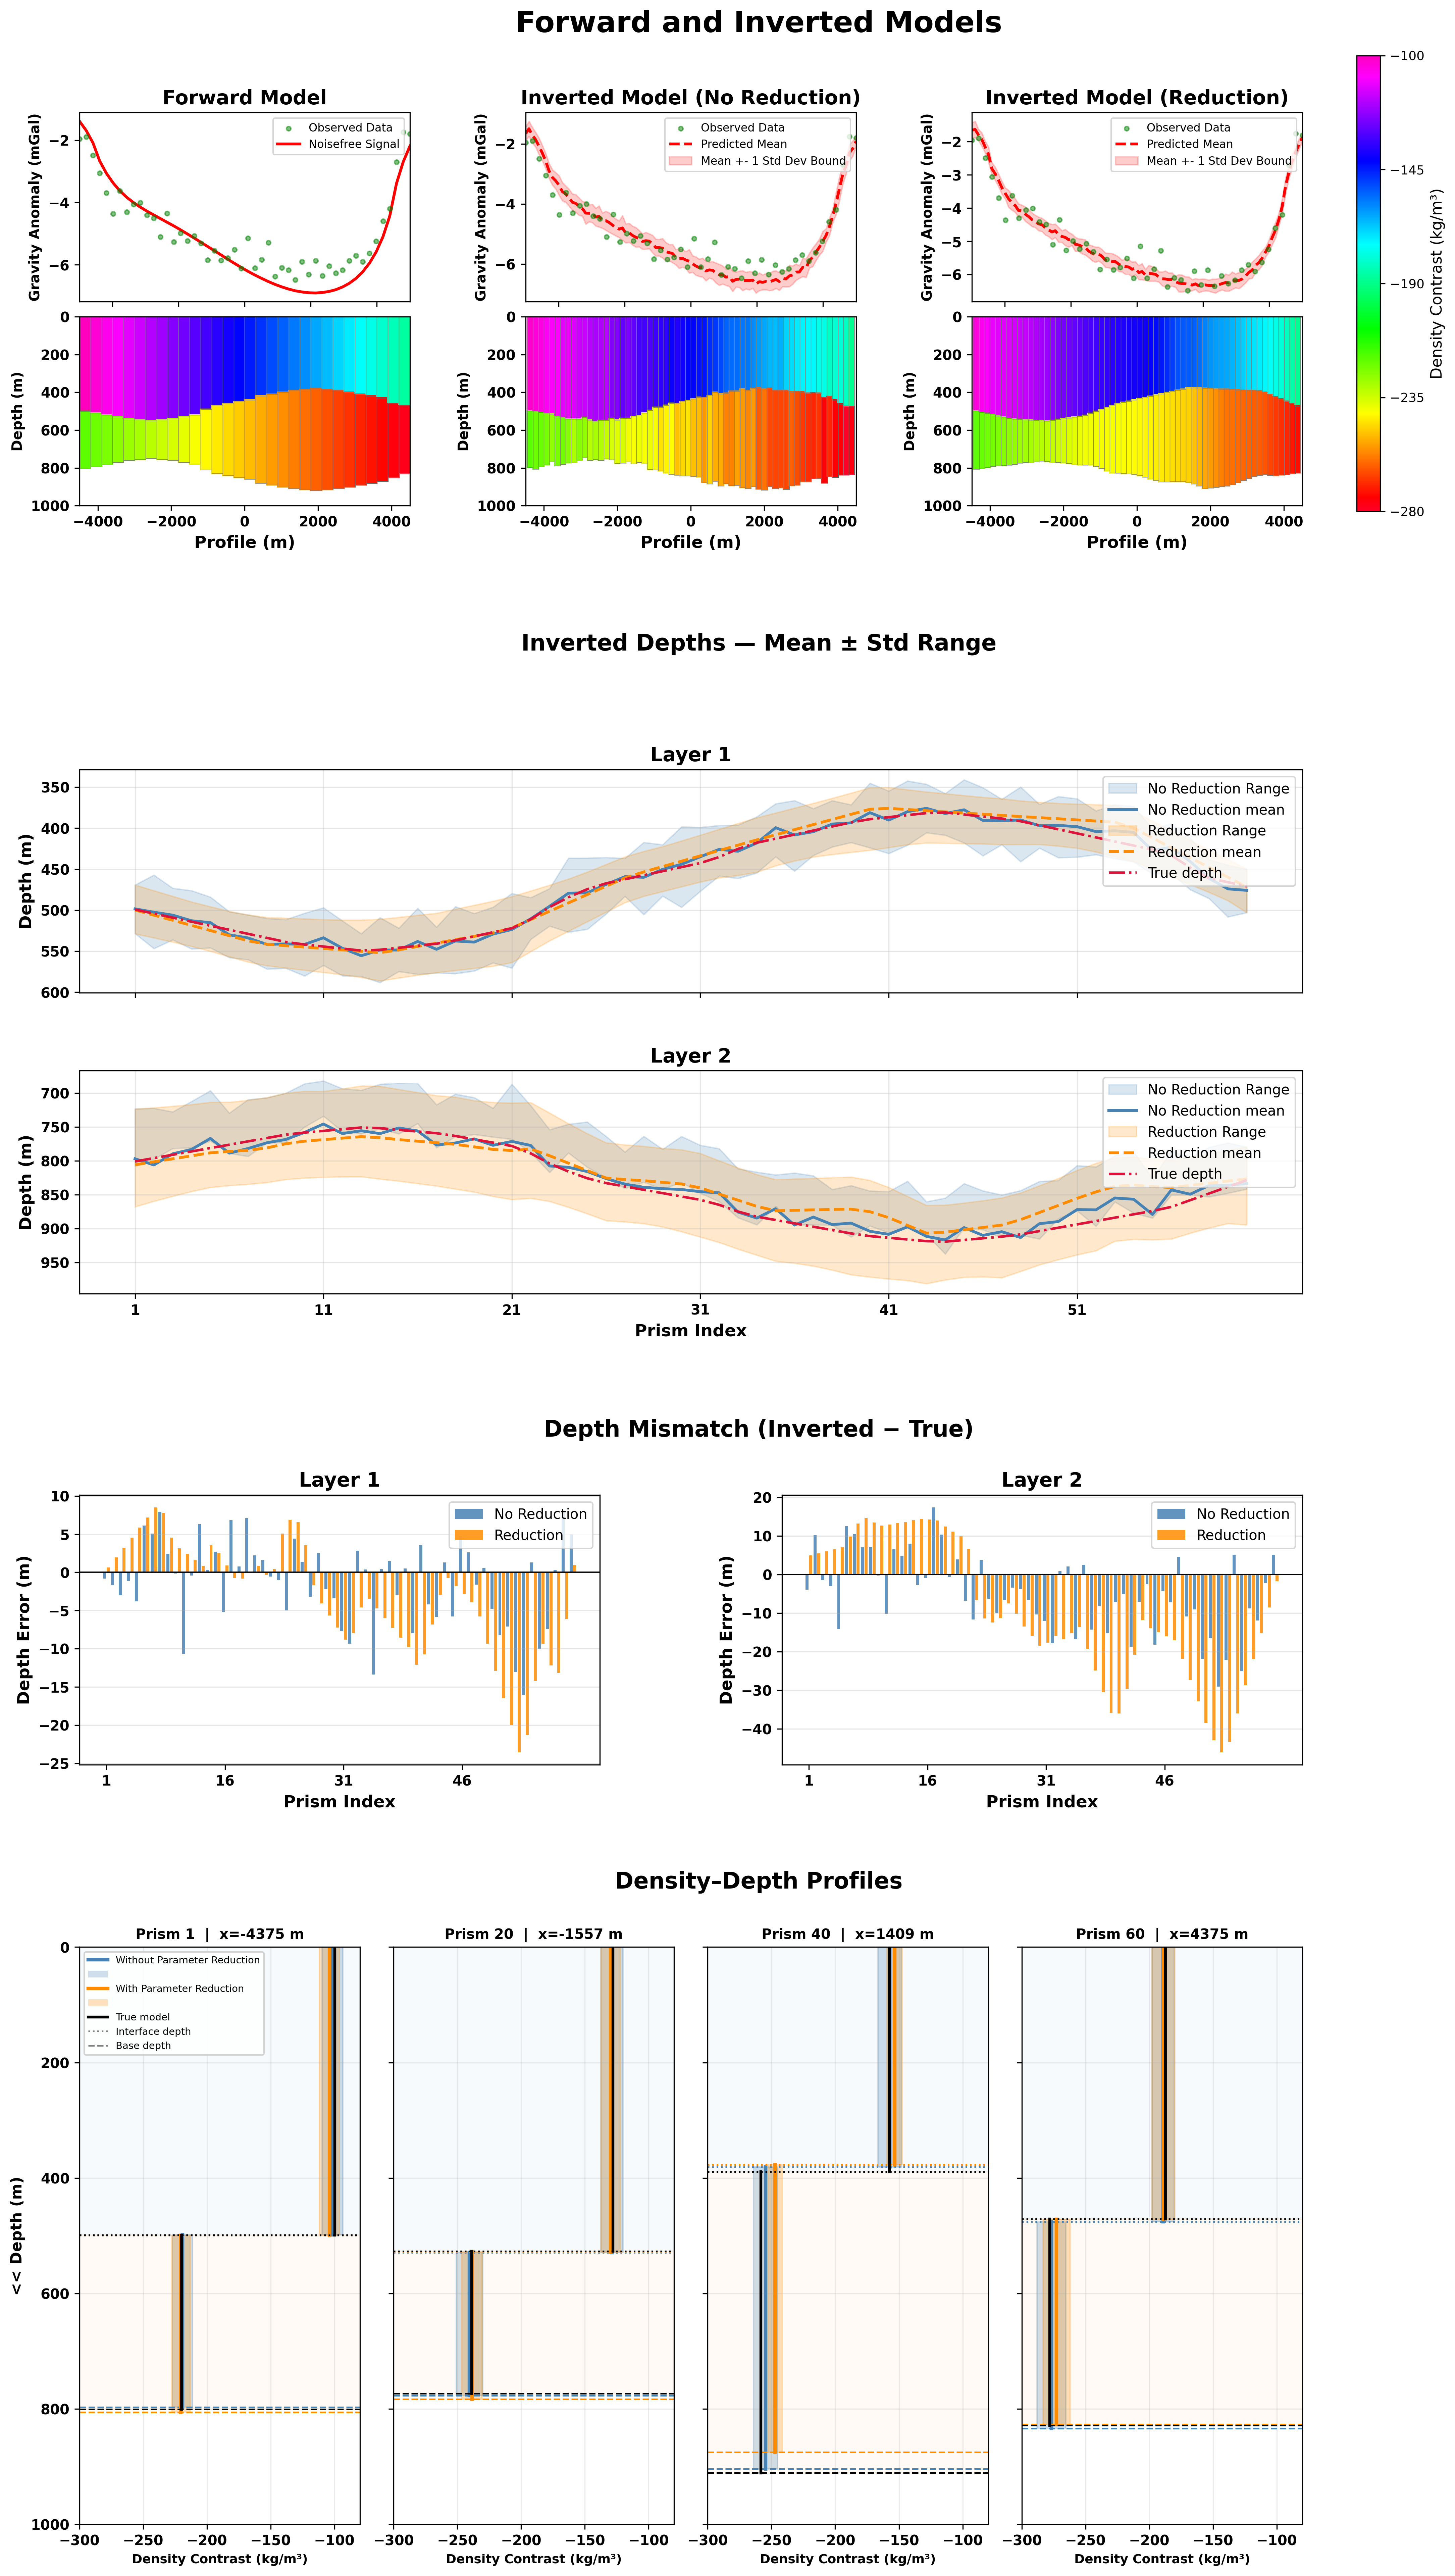

In [ ]:
# =============================================================================
# MERGED FIGURE — All four figures combined
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

true_rho1 = den1_L
true_rho2 = den2_L
prism_idx = np.arange(1, n1 + 1)

C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

# ── Density profile colors (kept consistent with merged palette) ──
C_GP   = 'steelblue'
C_AL   = 'darkorange'
C_TRUE_PROF = 'black'

vmin, vmax = -280, -100
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

#Creating x co-ordinate values for 1st layer for each prism
xs_1=np.zeros(n1+1)
xs_1[0]=co1[0]-(wid1[0]*0.5)
xs_1[n1]=co1[n1-1]+(wid1[n1-1]*0.5)
for i in range(1,n1):
    xs_1[i]=co1[i-1]+(0.5*wid1[i-1])

selected_prisms = [0, 19, 39, 59]
n_sel = len(selected_prisms)

original_X=X
pred_mean1 = np.array(y_sampled1.mean(0))
pred_std1  = np.array(y_sampled1.std(0))
pred_mean2 = np.array(y_sampled3.mean(0))
pred_std2  = np.array(y_sampled3.std(0))

X_test_np = np.array(X_test).flatten()

# =============================================================================
# BUILD MERGED FIGURE  (4 subfigures)
# =============================================================================
fig_merged = plt.figure(figsize=(18, 26), dpi=300)

# Fig1=6, Fig2=8, Fig3=4, Fig4=8 → ratios
subfigs = fig_merged.subfigures(4, 1,
                                 height_ratios=[6, 8, 4, 8],
                                 hspace=0.08)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 1 — Forward and Inverted Models
# ─────────────────────────────────────────────────────────────────────────────
subfigs[0].suptitle("Forward and Inverted Models",
                    fontsize=21, weight="bold")

axs1 = subfigs[0].subplots(2, 3)
subfigs[0].subplots_adjust(right=0.80, wspace=0.35, hspace=0.08, top=0.80)

def plot_cross_section(ax,N,XS, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None, Gravity_anomaly=None, vmin=-280, vmax=-120):

    sc = None  # default — returned even if no active learning points

    # ── Top row: Gravity anomaly ──────────────────────────────────────────────
    ax[0].scatter(X, np.array(y).flatten(),
                  alpha=0.5, c='green', marker='o', s=10,
                  label="Observed Data", zorder=2)

    if Gravity_anomaly is not None:
        ax[0].plot(X, Gravity_anomaly, c='red', linewidth=2,
                   label='Noisefree Signal', zorder=1)

    # ── Logic for Predicted Mean and Uncertainty ──────────────────────────────
    if predicted_mean is not None:
        ax[0].plot(X_test, predicted_mean, '--', c='red', linewidth=2,
                   label='Predicted Mean', zorder=1)

        if predicted_std is not None and not np.all(predicted_std == 0):
            ax[0].fill_between(X_test,
                               predicted_mean - predicted_std,
                               predicted_mean + predicted_std,
                               color='r', alpha=0.2, label="Mean +- 1 Std Dev Bound")

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight="bold")
    ax[0].set_title(title, fontsize=14, weight="bold")
    ax[0].legend(fontsize=8, loc="upper right")
    plt.setp(ax[0].get_xticklabels(), visible=False)
    plt.setp(ax[0].get_yticklabels(), visible=True, weight='bold')

    # ── Bottom row: Cross-section model ──────────────────────────────────────
    for i in range(N):
        xl = XS[i]
        xr = XS[i + 1]

        # Layer 1
        col1 = cmap(norm(INV_DEN_TOP[i]))
        ax[1].fill([xl, xr, xr, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i]], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i], 0.0],
                   color="grey", lw=0.3)

        # Layer 2
        col2 = cmap(norm(INV_DEN_BOTTOM[i]))
        ax[1].fill([xl, xr, xr, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i]],
                   color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i], INV_DEP_TOP[i]],
                   color="grey", lw=0.3)

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", fontsize=12, weight="bold")
    ax[1].set_ylabel("Depth (m)", fontsize=10, weight="bold")
    plt.setp(ax[1].get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible=True, weight='bold')

    return sc

plot_cross_section(axs1[:, 0],n,xs, bd1, den1_L, bd2, den2_L,
                   "Forward Model", Gravity_anomaly=measure_func(X))

plot_cross_section(axs1[:, 1],n1,xs_1,
                         top_inverted_depths1, top_density1,
                         bottom_inverted_depths1, bottom_density1,
                         "Inverted Model (No Reduction)",
                         predicted_mean=pred_mean_r1, predicted_std=pred_std_r1)

plot_cross_section(axs1[:, 2],n1,xs_1,
                         top_inverted_depths3, top_density3,
                         bottom_inverted_depths3, bottom_density3,
                         "Inverted Model (Reduction)",
                         predicted_mean=pred_mean3, predicted_std=pred_std3)

# Density contrast colorbar
cbar_ax_den = subfigs[0].add_axes([0.83, 0.10, 0.013, 0.80])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_den = subfigs[0].colorbar(sm, cax=cbar_ax_den, orientation="vertical",
                                ticks=np.linspace(vmin, vmax, 5))
cbar_den.set_label("Density Contrast (kg/m³)", fontsize=11)
cbar_den.ax.tick_params(labelsize=9)



# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 2 — Per-prism depth comparison
# ─────────────────────────────────────────────────────────────────────────────
subfigs[1].suptitle("Inverted Depths — Mean ± Std Range",
                    fontsize=16, weight="bold")

axs2 = subfigs[1].subplots(2, 1, sharex=True)

depth_pairs = [
    (axs2[0], "Layer 1",
     top_inverted_depths1, top_inverted_depths1_min, top_inverted_depths1_max,
     top_inverted_depths3, top_inverted_depths3_min, top_inverted_depths3_max,
     bd1_0),
    (axs2[1], "Layer 2",
     bottom_inverted_depths1, bottom_inverted_depths1_min, bottom_inverted_depths1_max,
     bottom_inverted_depths3, bottom_inverted_depths3_min, bottom_inverted_depths3_max,
     bd2_0),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    ax.fill_between(prism_idx, n_min, n_max, color=C_NARROW, alpha=ALPHA_BAND, label="No Reduction Range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2, label="No Reduction mean")
    ax.fill_between(prism_idx, s_min, s_max, color=C_SPARSE, alpha=ALPHA_BAND, label="Reduction Range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--", label="Reduction mean")
    ax.plot(prism_idx, true_d, color=C_TRUE,   lw=1.8, ls="-.", label="True depth")
    ax.set_ylabel("Depth (m)", fontsize=12, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx[::10])
plt.setp(axs2[1].get_xticklabels(), visible=True, weight='bold')
subfigs[1].subplots_adjust(hspace=0.35)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 3 — Depth error bar charts
# ─────────────────────────────────────────────────────────────────────────────
subfigs[2].suptitle("Depth Mismatch (Inverted − True)",
                    fontsize=16, weight="bold", y=1.02)

axs3 = subfigs[2].subplots(1, 2)
subfigs[2].subplots_adjust(top=0.82)

bar_w  = 0.38
offset = bar_w / 2 + 0.04

depth_specs = [
    ("Layer 1", top_inverted_depths1 - bd1_0,    top_inverted_depths3 - bd1_0,    axs3[0]),
    ("Layer 2", bottom_inverted_depths1 - bd2_0,  bottom_inverted_depths3 - bd2_0, axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w, color=C_NARROW, alpha=0.85, label="No Reduction")
    ax.bar(prism_idx + offset, s_vals, width=bar_w, color=C_SPARSE,  alpha=0.85, label="Reduction")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=12, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(prism_idx[::15])
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 4 — Density–Depth Profiles: GP vs Active Learning
# ─────────────────────────────────────────────────────────────────────────────
subfigs[3].suptitle(
    "Density–Depth Profiles",
    fontsize=16, weight="bold"
)

axs4 = subfigs[3].subplots(1, n_sel, sharey=True)
subfigs[3].subplots_adjust(wspace=0.12, top=0.88, bottom=0.12)

for ax, i in zip(axs4, selected_prisms):

    # ── True model ───────────────────────────────────────────
    rho1_true   = den1_L0[i]
    rho2_true   = den2_L0[i]
    true_depth1 = bd1_0[i]
    true_depth2 = bd2_0[i]
    z_true1     = np.array([0,           true_depth1])
    z_true2     = np.array([true_depth1, true_depth2])

    # ── Structural GP ────────────────────────────────────────
    gp_rho1_mean  = top_density1[i]
    gp_rho1_std   = top_density1_std[i]
    gp_rho2_mean  = bottom_density1[i]
    gp_rho2_std   = bottom_density1_std[i]
    gp_inv_depth1 = top_inverted_depths1[i]
    gp_inv_depth2 = bottom_inverted_depths1[i]
    gp_z1         = np.array([0,             gp_inv_depth1])
    gp_z2         = np.array([gp_inv_depth1, gp_inv_depth2])

    # ── Active Learning ──────────────────────────────────────
    al_rho1_mean  = top_density3[i]
    al_rho1_std   = top_density3_std[i]
    al_rho2_mean  = bottom_density3[i]
    al_rho2_std   = bottom_density3_std[i]
    al_inv_depth1 = top_inverted_depths3[i]
    al_inv_depth2 = bottom_inverted_depths3[i]
    al_z1         = np.array([0,             al_inv_depth1])
    al_z2         = np.array([al_inv_depth1, al_inv_depth2])

    # ── Plot GP bands + mean ─────────────────────────────────
    for z_span, rho_mean, rho_std in [
        (gp_z1, gp_rho1_mean, gp_rho1_std),
        (gp_z2, gp_rho2_mean, gp_rho2_std),
    ]:
        ax.fill_betweenx(z_span,
                         rho_mean - rho_std, rho_mean + rho_std,
                         alpha=0.25, color=C_GP)
        ax.plot([rho_mean, rho_mean], z_span,
                color=C_GP, linewidth=2.5)

    ax.axhline(gp_inv_depth1, color=C_GP, linestyle=':',  linewidth=1.2)
    ax.axhline(gp_inv_depth2, color=C_GP, linestyle='--', linewidth=1.2)

    # ── Plot AL bands + mean ─────────────────────────────────
    for z_span, rho_mean, rho_std in [
        (al_z1, al_rho1_mean, al_rho1_std),
        (al_z2, al_rho2_mean, al_rho2_std),
    ]:
        ax.fill_betweenx(z_span,
                         rho_mean - rho_std, rho_mean + rho_std,
                         alpha=0.25, color=C_AL)
        ax.plot([rho_mean, rho_mean], z_span,
                color=C_AL, linewidth=2.5)

    ax.axhline(al_inv_depth1, color=C_AL, linestyle=':',  linewidth=1.2)
    ax.axhline(al_inv_depth2, color=C_AL, linestyle='--', linewidth=1.2)

    # ── True model (on top) ──────────────────────────────────
    ax.plot([rho1_true, rho1_true], z_true1,
            color=C_TRUE_PROF, linestyle='-', linewidth=2.0)
    ax.plot([rho2_true, rho2_true], z_true2,
            color=C_TRUE_PROF, linestyle='-', linewidth=2.0)
    ax.axhline(true_depth1, color=C_TRUE_PROF, linestyle=':',  linewidth=1.2)
    ax.axhline(true_depth2, color=C_TRUE_PROF, linestyle='--', linewidth=1.2)

    # ── Background layer shading ─────────────────────────────
    ax.axhspan(0,           true_depth1, alpha=0.04, color=C_GP)
    ax.axhspan(true_depth1, true_depth2, alpha=0.04, color=C_AL)

    # ── Legend — first panel only ────────────────────────────
    if i == selected_prisms[0]:
        legend_elements = [
            Line2D([0],[0], color=C_GP,         lw=2.5,  label='Without Parameter Reduction'),
            Patch(facecolor=C_GP,   alpha=0.25,label=None),
            Line2D([0],[0], color=C_AL,         lw=2.5,  label='With Parameter Reduction'),
            Patch(facecolor=C_AL,   alpha=0.25,label=None),
            Line2D([0],[0], color=C_TRUE_PROF,  lw=2.0,  label='True model'),
            Line2D([0],[0], color='gray', lw=1.2, ls=':',  label='Interface depth'),
            Line2D([0],[0], color='gray', lw=1.2, ls='--', label='Base depth'),
        ]
        ax.legend(handles=legend_elements, fontsize=7,
                  loc='upper left', framealpha=0.85)

    ax.set_title(f"Prism {i+1}  |  x={co1[i]:.0f} m", fontsize=10, weight='bold')
    ax.set_xlabel("Density Contrast (kg/m³)", fontsize=9,weight='bold')
    ax.set_xlim(-300, -80)
    ax.set_ylim(1000, 0)
    ax.grid(True, alpha=0.25)

axs4[0].set_ylabel("<< Depth (m)", fontsize=11, weight='bold')
plt.setp(axs4[0].get_xticklabels(), weight='bold')
plt.setp(axs4[0].get_yticklabels(), weight='bold')
plt.setp(axs4[1].get_xticklabels(), weight='bold')
plt.setp(axs4[2].get_xticklabels(), weight='bold')
plt.setp(axs4[3].get_xticklabels(), weight='bold')
plt.setp(axs4[4].get_yticklabels(), weight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# SAVE & SHOW
# ─────────────────────────────────────────────────────────────────────────────
#plt.savefig("merged_figure_all4.png", dpi=300, bbox_inches='tight')
plt.show()